# Construcción del IC — Seguro Indexado Caldas
**Pipeline:** Parquet → PCA + WI → Backtest → PA2 (VAL) → Selección → Test final → STL → Export

---
## Tabla de contenidos
1. Configuración y carga
2. PA1 — Construcción del IC (2a PCA, 2b WI, 2c Backtest, 2d Diagnóstico)
3. PA2 — Dependencia IC ↔ NDVI_anom sobre VAL (3a Estratos, 3b QR, 3c OLS, 3d Selección + Test)
4. STL — Solo sobre IC definitivo
5. Exportación


## 1. Configuración y carga de datos

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, joblib, os, warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print(f"Semilla global: {SEED}")

# ── Rutas ──────────────────────────────────────────────────────────
INPUT_DIR  = 'output'    # parquets generados por Procesamiento_v3
OUTPUT_DIR = 'output_ic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Cargar splits ──────────────────────────────────────────────────
df_train = pd.read_parquet(f'{INPUT_DIR}/df_train.parquet')
df_val   = pd.read_parquet(f'{INPUT_DIR}/df_val.parquet')
df_test  = pd.read_parquet(f'{INPUT_DIR}/df_test.parquet')

# Variables Z que entran al IC (11 variables)
COLS_Z = [
    'Z_tmax', 'Z_tmin', 'Z_skin_temp', 'Z_ppt', 'Z_srad',
    'Z_pet', 'Z_soil_water', 'Z_vap', 'Z_vpd', 'Z_ws', 'Z_BAL'
]

#COLS_Z = [
#     'Z_skin_temp', 'Z_ppt', 'Z_srad',
#    'Z_pet', 'Z_soil_water', 'Z_vap', 'Z_vpd', 'Z_ws'
#]

print('Splits cargados:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n_ndvi = df['NDVI_anom'].notna().sum()
    print(f'  {nombre}: {len(df):,} filas | '
          f'{df["fecha"].min().date()} → {df["fecha"].max().date()} | '
          f'NDVI válido: {n_ndvi:,} ({n_ndvi/len(df)*100:.1f}%)')

print(f'\nVariables Z disponibles: {len(COLS_Z)}')
print(f'NaN en variables Z (train): {df_train[COLS_Z].isna().sum().sum()}')

Semilla global: 42
Splits cargados:
  TRAIN: 17,934 filas | 2003-01-01 → 2018-12-28 | NDVI válido: 8,829 (49.2%)
  VAL: 3,332 filas | 2019-01-13 → 2021-12-20 | NDVI válido: 1,423 (42.7%)
  TEST: 4,802 filas | 2022-01-05 → 2026-04-06 | NDVI válido: 2,097 (43.7%)

Variables Z disponibles: 11
NaN en variables Z (train): 0


## 2. Pregunta analítica 1 — Construcción del IC

Se implementan **dos alternativas** sobre las 11 variables Z estandarizadas por DOY:
- **IC_PCA**: primer componente principal
- **IC_WI**: weighted index con pesos = correlación Spearman con NDVI_anom en train

La selección definitiva se realiza al final de la Pregunta Analítica 2.

Filas para PCA (train, sin NaN): 17,934 de 17,934 (100.0%)

Varianza explicada por componente:
  PC1: 44.8%
  PC2: 25.8%
  PC3: 9.9%
  PC4: 7.8%
  PC5: 5.2%
  PC1 acumula 44.8% — ✅ >= 40%

Loadings PC1 (pesos PCA):
Z_BAL          -0.383
Z_ppt          -0.378
Z_soil_water   -0.347
Z_vap          -0.287
Z_tmin          0.017
Z_tmax          0.044
Z_skin_temp     0.050
Z_ws            0.229
Z_srad          0.364
Z_pet           0.391
Z_vpd           0.406

IC_PCA generado:
  TRAIN: media=0.000 | std=2.219 | rango=[-6.93, 7.92]
  VAL: media=0.504 | std=2.552 | rango=[-7.78, 8.87]
  TEST: media=-0.216 | std=2.474 | rango=[-8.99, 8.30]


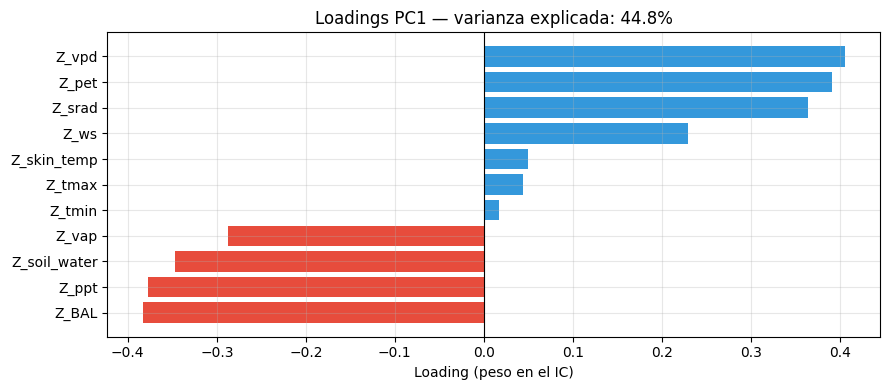

In [5]:
# =====================================================================
# 2a. PCA → IC_PCA
#
# Se ajusta PCA sobre df_train (sin NaN en COLS_Z).
# Se aplica a los tres splits.
# El IC es el primer componente principal, estandarizado a z-score.
# =====================================================================

# Filas completas en train (sin NaN en variables Z)
train_pca = df_train[COLS_Z].dropna()
print(f'Filas para PCA (train, sin NaN): {len(train_pca):,} '
      f'de {len(df_train):,} ({len(train_pca)/len(df_train)*100:.1f}%)')

# Ajustar PCA en train
np.random.seed(SEED)
pca = PCA(n_components=len(COLS_Z))
pca.fit(train_pca)

var_explicada = pca.explained_variance_ratio_
print(f'\nVarianza explicada por componente:')
for i, v in enumerate(var_explicada[:5]):
    print(f'  PC{i+1}: {v*100:.1f}%')
print(f'  PC1 acumula {var_explicada[0]*100:.1f}% — '
      f'{"✅ >= 40%" if var_explicada[0] >= 0.4 else "⚠️ < 40% — revisar"}')

# Pesos (loadings) del primer componente
loadings_pca = pd.Series(pca.components_[0], index=COLS_Z).sort_values()
print(f'\nLoadings PC1 (pesos PCA):')
print(loadings_pca.round(3).to_string())

# Aplicar a los tres splits
def aplicar_pca(df, pca_model, cols_z):
    df = df.copy()
    mask = df[cols_z].notna().all(axis=1)
    ic = np.full(len(df), np.nan)
    if mask.sum() > 0:
        scores = pca_model.transform(df.loc[mask, cols_z])
        ic[mask] = scores[:, 0]
    df['IC_PCA'] = ic
    return df

df_train = aplicar_pca(df_train, pca, COLS_Z)
df_val   = aplicar_pca(df_val,   pca, COLS_Z)
df_test  = aplicar_pca(df_test,  pca, COLS_Z)

print(f'\nIC_PCA generado:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    ic = df['IC_PCA'].dropna()
    print(f'  {nombre}: media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Visualización de loadings
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C' if v < 0 else '#3498DB' for v in loadings_pca.values]
ax.barh(loadings_pca.index, loadings_pca.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Loadings PC1 — varianza explicada: {var_explicada[0]*100:.1f}%')
ax.set_xlabel('Loading (peso en el IC)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Filas para WI (train, con NDVI válido): 8,829

Correlaciones Spearman Z_var ↔ NDVI_anom (train):
Z_srad          0.443
Z_pet           0.395
Z_vpd           0.285
Z_ws            0.150
Z_tmax          0.004
Z_soil_water   -0.221
Z_ppt          -0.239
Z_BAL          -0.248
Z_skin_temp    -0.258
Z_tmin         -0.280
Z_vap          -0.538

Pesos WI (normalizados, suma abs = 1.000):
Z_srad          0.145
Z_pet           0.129
Z_vpd           0.093
Z_ws            0.049
Z_tmax          0.001
Z_soil_water   -0.072
Z_ppt          -0.078
Z_BAL          -0.081
Z_skin_temp    -0.084
Z_tmin         -0.092
Z_vap          -0.176

IC_WI generado:
  TRAIN: media=-0.000 | std=0.687 | rango=[-1.66, 2.20]
  VAL: media=0.114 | std=0.765 | rango=[-1.73, 2.18]
  TEST: media=-0.099 | std=0.755 | rango=[-2.01, 2.32]


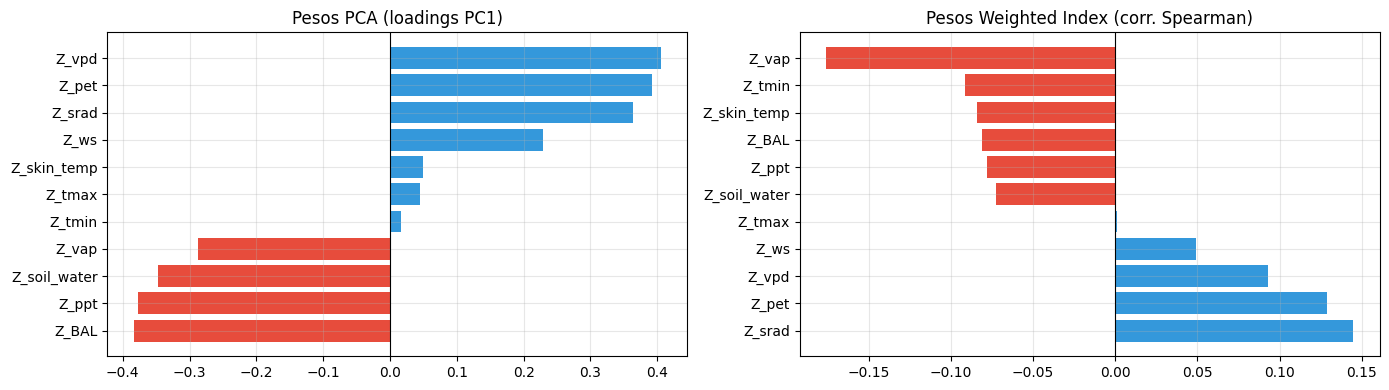

In [6]:
# =====================================================================
# 2b. Weighted Index → IC_WI
#
# Pesos = correlación de Spearman entre cada Z_var y NDVI_anom en TRAIN.
# Solo se usan filas donde NDVI_anom no es NaN para calcular los pesos.
# Se normalizan los pesos para que sumen 1 en valor absoluto.
# Se aplica a los tres splits usando los pesos de TRAIN.
#
# Nota: esto introduce dependencia entre construcción del IC y la
# variable de validación. Los pesos se calculan SOLO en train y no
# se reajustan, para evitar data leakage.
# =====================================================================

# Calcular correlaciones Spearman en train (solo filas con NDVI válido)
train_wi = df_train[COLS_Z + ['NDVI_anom']].dropna()
print(f'Filas para WI (train, con NDVI válido): {len(train_wi):,}')

correlaciones = {}
for col in COLS_Z:
    r, p = stats.spearmanr(train_wi[col], train_wi['NDVI_anom'])
    correlaciones[col] = r

corr_series = pd.Series(correlaciones).sort_values(ascending=False)
print('\nCorrelaciones Spearman Z_var ↔ NDVI_anom (train):')
print(corr_series.round(3).to_string())

# Pesos normalizados (suma de valores absolutos = 1)
pesos_wi = corr_series / corr_series.abs().sum()
print(f'\nPesos WI (normalizados, suma abs = {pesos_wi.abs().sum():.3f}):')
print(pesos_wi.round(3).to_string())

# Aplicar a los tres splits
def aplicar_wi(df, pesos, cols_z):
    df = df.copy()
    mask = df[cols_z].notna().all(axis=1)
    ic = np.full(len(df), np.nan)
    if mask.sum() > 0:
        X = df.loc[mask, cols_z]
        ic[mask] = X.values @ pesos[cols_z].values
    df['IC_WI'] = ic
    return df

df_train = aplicar_wi(df_train, pesos_wi, COLS_Z)
df_val   = aplicar_wi(df_val,   pesos_wi, COLS_Z)
df_test  = aplicar_wi(df_test,  pesos_wi, COLS_Z)

print(f'\nIC_WI generado:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    ic = df['IC_WI'].dropna()
    print(f'  {nombre}: media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Comparación de pesos PCA vs WI
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (valores, titulo) in zip(axes, [
    (loadings_pca, 'Pesos PCA (loadings PC1)'),
    (pesos_wi,     'Pesos Weighted Index (corr. Spearman)')
]):
    cols = list(valores.index)
    vals = list(valores.values)
    colors = ['#E74C3C' if v < 0 else '#3498DB' for v in vals]
    ax.barh(cols, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# =====================================================================
# 2b.2  Corrección de signo del IC_PCA + análisis de rezago
#
# PLAN 1 — Corrección de signo:
#   El primer componente principal tiene signo arbitrario. Si el IC_PCA
#   sale con signo invertido, valores altos del IC corresponden a estrés
#   (bajo NDVI) y el trigger IC < p10 captura las observaciones incorrectas.
#   Se verifica la correlación Spearman IC_PCA ↔ NDVI_anom en train:
#   - Si ρ < 0: el IC está invertido → negarlo
#   - Si ρ > 0: el IC ya está en la dirección correcta
#
# PLAN 2 — Rezago temporal:
#   El NDVI puede responder al estrés climático con 1–3 períodos de retraso
#   (16–48 días). Si la correlación mejora con rezago, se usa el IC rezagado
#   como predictor. Se evalúa sobre AMBOS ICs (PCA y WI).
# =====================================================================

# ── PLAN 1: Verificar y corregir signo ───────────────────────────────

for nombre_ic, col_ic in [('IC_PCA', 'IC_PCA'), ('IC_WI', 'IC_WI')]:
    train_valido = df_train[[col_ic, 'NDVI_anom']].dropna()
    corr, _ = stats.spearmanr(train_valido[col_ic], train_valido['NDVI_anom'])
    print(f"Correlación {nombre_ic} ↔ NDVI_anom (train): ρ = {corr:.3f}")

    if corr < 0:
        print(f"  → ρ < 0: {nombre_ic} está invertido. Negando...")
        for df in [df_train, df_val, df_test]:
            df[col_ic] = -df[col_ic]
        # Verificar corrección
        train_valido2 = df_train[[col_ic, 'NDVI_anom']].dropna()
        corr2, _ = stats.spearmanr(train_valido2[col_ic],
                                    train_valido2['NDVI_anom'])
        print(f"  → Correlación después de corrección: ρ = {corr2:.3f} ✅")
    else:
        print(f"  → ρ > 0: {nombre_ic} ya está en la dirección correcta ✅")
    print()

# ── PLAN 2: Análisis de rezago ────────────────────────────────────────
# Se evalúa lag 0, 1, 2, 3 (0, 16, 32, 48 días) para ambos ICs.
# Los parámetros se calculan pixel a pixel para evitar mezclar
# series temporales de distintas ubicaciones geográficas.

print("\n=== ANÁLISIS DE REZAGO (train) ===")
print("Correlación Spearman IC(t-lag) ↔ NDVI_anom(t)")
print("─" * 50)

train_sorted = df_train.sort_values(['lat', 'lon', 'fecha'])

lag_results = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    lag_results[col_ic] = {}
    pares_por_lag = {lag: [] for lag in range(4)}

    for (lat, lon), grupo in train_sorted.groupby(['lat', 'lon']):
        grupo = grupo.sort_values('fecha').reset_index(drop=True)
        ndvi  = grupo['NDVI_anom']
        for lag in range(4):
            ic_lag = grupo[col_ic].shift(lag)
            validos = ic_lag.notna() & ndvi.notna()
            if validos.sum() >= 10:
                pares_por_lag[lag].append(
                    pd.DataFrame({'ic': ic_lag[validos].values,
                                  'ndvi': ndvi[validos].values})
                )

    print(f"\n  {col_ic}:")
    mejor_lag = 0
    mejor_corr = -999
    for lag in range(4):
        if pares_por_lag[lag]:
            df_pares = pd.concat(pares_por_lag[lag], ignore_index=True)
            r, _ = stats.spearmanr(df_pares['ic'], df_pares['ndvi'])
            lag_results[col_ic][lag] = round(r, 4)
            marker = ''
            if r > mejor_corr:
                mejor_corr = r
                mejor_lag  = lag
            print(f"    Lag {lag} ({lag*16:2d} días): ρ = {r:.4f}")
        else:
            lag_results[col_ic][lag] = None
            print(f"    Lag {lag}: sin datos suficientes")

    mejora = lag_results[col_ic][mejor_lag] - lag_results[col_ic][0]
    print(f"    → Mejor lag: {mejor_lag} ({mejor_lag*16} días), "
          f"ρ = {lag_results[col_ic][mejor_lag]:.4f} "
          f"(mejora vs lag0: {mejora:+.4f})")

    if mejor_lag > 0 and mejora > 0.02:
        print(f"    ⚠️  El rezago mejora la correlación en > 0.02.")
        print(f"       Considerar usar IC rezagado {mejor_lag} período(s) "
              f"como predictor en PA2.")
    else:
        print(f"    ✅  El rezago no mejora significativamente (< 0.02).")
        print(f"       Se usa lag=0 (contemporáneo).")


Correlación IC_PCA ↔ NDVI_anom (train): ρ = 0.346
  → ρ > 0: IC_PCA ya está en la dirección correcta ✅

Correlación IC_WI ↔ NDVI_anom (train): ρ = 0.495
  → ρ > 0: IC_WI ya está en la dirección correcta ✅


=== ANÁLISIS DE REZAGO (train) ===
Correlación Spearman IC(t-lag) ↔ NDVI_anom(t)
──────────────────────────────────────────────────

  IC_PCA:
    Lag 0 ( 0 días): ρ = 0.3465
    Lag 1 (16 días): ρ = 0.3346
    Lag 2 (32 días): ρ = 0.3463
    Lag 3 (48 días): ρ = 0.3382
    → Mejor lag: 0 (0 días), ρ = 0.3465 (mejora vs lag0: +0.0000)
    ✅  El rezago no mejora significativamente (< 0.02).
       Se usa lag=0 (contemporáneo).

  IC_WI:
    Lag 0 ( 0 días): ρ = 0.4952
    Lag 1 (16 días): ρ = 0.4809
    Lag 2 (32 días): ρ = 0.4913
    Lag 3 (48 días): ρ = 0.4880
    → Mejor lag: 0 (0 días), ρ = 0.4952 (mejora vs lag0: +0.0000)
    ✅  El rezago no mejora significativamente (< 0.02).
       Se usa lag=0 (contemporáneo).


Teniendo presente que el rezago no mejora significativamente ni en PCA ni en WI, se usa lag = 0

In [9]:
# =====================================================================
# 2c. Backtest de estabilidad — expanding window
#
# Se reportan variación RELATIVA (std/mean_abs) y ABSOLUTA (std).
# La variación relativa es engañosa cuando el loading es ~0:
# un loading de 0.002 ± 0.005 tiene variación relativa del 250%
# pero impacto negligible en el IC.
# Criterio real de inestabilidad: rel > 15% AND abs > 0.01.
# =====================================================================

df_all_train = df_train.copy()
anios_train  = sorted(df_all_train['fecha'].dt.year.unique())
ventanas     = [(anios_train[0], y) for y in anios_train[5::3]]

print(f'Expanding window backtest — {len(ventanas)} ventanas:')

loadings_por_ventana_pca = []
pesos_por_ventana_wi     = []

for inicio, fin in ventanas:
    np.random.seed(SEED)
    mask   = (df_all_train['fecha'].dt.year >= inicio) & \
             (df_all_train['fecha'].dt.year <= fin)
    subset = df_all_train.loc[mask, COLS_Z].dropna()
    if len(subset) < 30:
        continue

    pca_v = PCA(n_components=1)
    pca_v.fit(subset)
    loadings_v = pd.Series(pca_v.components_[0], index=COLS_Z)
    if np.corrcoef(loadings_v.values,
                   loadings_pca.reindex(COLS_Z).values)[0,1] < 0:
        loadings_v = -loadings_v
    loadings_por_ventana_pca.append((fin, loadings_v))

    subset_wi = df_all_train.loc[mask, COLS_Z + ['NDVI_anom']].dropna()
    if len(subset_wi) > 10:
        corr_v = {c: stats.spearmanr(subset_wi[c],
                  subset_wi['NDVI_anom'])[0] for c in COLS_Z}
        pesos_v = pd.Series(corr_v)
        pesos_v = pesos_v / pesos_v.abs().sum()
        pesos_por_ventana_wi.append((fin, pesos_v))

    print(f'  Ventana {inicio}–{fin}: {len(subset):,} obs. PCA | '
          f'{len(subset_wi):,} obs. WI')

# ── Métricas PCA ──────────────────────────────────────────────────────
if len(loadings_por_ventana_pca) >= 2:
    df_load_pca      = pd.DataFrame(
        {fin: l for fin, l in loadings_por_ventana_pca}).T
    variacion_rel_pca = df_load_pca.std() / df_load_pca.abs().mean()
    variacion_abs_pca = df_load_pca.std()

    print('\nEstabilidad PCA — por variable (relativa | absoluta):')
    for col in variacion_rel_pca.sort_values(ascending=False).index:
        vr = variacion_rel_pca[col]
        va = variacion_abs_pca[col]
        if vr > 0.15 and va > 0.01:
            flag = '⚠️  inestabilidad real'
        elif vr > 0.15:
            flag = '~0  loading negligible (artefacto del indicador)'
        else:
            flag = '✅'
        print(f'  {col:<15}: rel={vr:.3f}  abs={va:.4f}  {flag}')

# ── Métricas WI ───────────────────────────────────────────────────────
if len(pesos_por_ventana_wi) >= 2:
    df_pesos_wi       = pd.DataFrame(
        {fin: p for fin, p in pesos_por_ventana_wi}).T
    variacion_rel_wi  = df_pesos_wi.std() / df_pesos_wi.abs().mean()
    variacion_abs_wi  = df_pesos_wi.std()

    print('\nEstabilidad WI — por variable (relativa | absoluta):')
    for col in variacion_rel_wi.sort_values(ascending=False).index:
        vr = variacion_rel_wi[col]
        va = variacion_abs_wi[col]
        if vr > 0.15 and va > 0.01:
            flag = '⚠️  inestabilidad real'
        elif vr > 0.15:
            flag = '~0  peso negligible'
        else:
            flag = '✅'
        print(f'  {col:<15}: rel={vr:.3f}  abs={va:.4f}  {flag}')


#Backtest para valores extremos
pesos_por_ventana_wi_ext = []
for inicio, fin in ventanas:
    np.random.seed(SEED)
    mask    = (df_train['fecha'].dt.year >= inicio) & (df_train['fecha'].dt.year <= fin)
    sub_ext = df_train.loc[mask, COLS_Z + ['NDVI_anom']].dropna()
    # Calcular pesos ext sobre extremos p20
    p20_ndvi = sub_ext['NDVI_anom'].quantile(0.20)
    sub_extremos = sub_ext[sub_ext['NDVI_anom'] < p20_ndvi]
    if len(sub_extremos) >= 30:
        corr_v = {c: stats.spearmanr(sub_extremos[c], sub_extremos['NDVI_anom'])[0]
                  for c in COLS_Z}
        pw = pd.Series(corr_v)
        pw = pw / pw.abs().sum()
        pesos_por_ventana_wi_ext.append((fin, pw))

Expanding window backtest — 4 ventanas:
  Ventana 2003–2008: 6,713 obs. PCA | 3,122 obs. WI
  Ventana 2003–2011: 10,094 obs. PCA | 4,583 obs. WI
  Ventana 2003–2014: 13,426 obs. PCA | 6,339 obs. WI
  Ventana 2003–2017: 16,807 obs. PCA | 8,200 obs. WI

Estabilidad PCA — por variable (relativa | absoluta):
  Z_tmin         : rel=1.053  abs=0.0134  ⚠️  inestabilidad real
  Z_tmax         : rel=0.686  abs=0.0148  ⚠️  inestabilidad real
  Z_skin_temp    : rel=0.406  abs=0.0129  ⚠️  inestabilidad real
  Z_ws           : rel=0.082  abs=0.0165  ✅
  Z_vpd          : rel=0.041  abs=0.0154  ✅
  Z_srad         : rel=0.030  abs=0.0115  ✅
  Z_vap          : rel=0.022  abs=0.0063  ✅
  Z_soil_water   : rel=0.022  abs=0.0074  ✅
  Z_ppt          : rel=0.019  abs=0.0075  ✅
  Z_BAL          : rel=0.019  abs=0.0076  ✅
  Z_pet          : rel=0.017  abs=0.0070  ✅

Estabilidad WI — por variable (relativa | absoluta):
  Z_tmax         : rel=1.159  abs=0.0064  ~0  peso negligible
  Z_soil_water   : rel=0.199  a

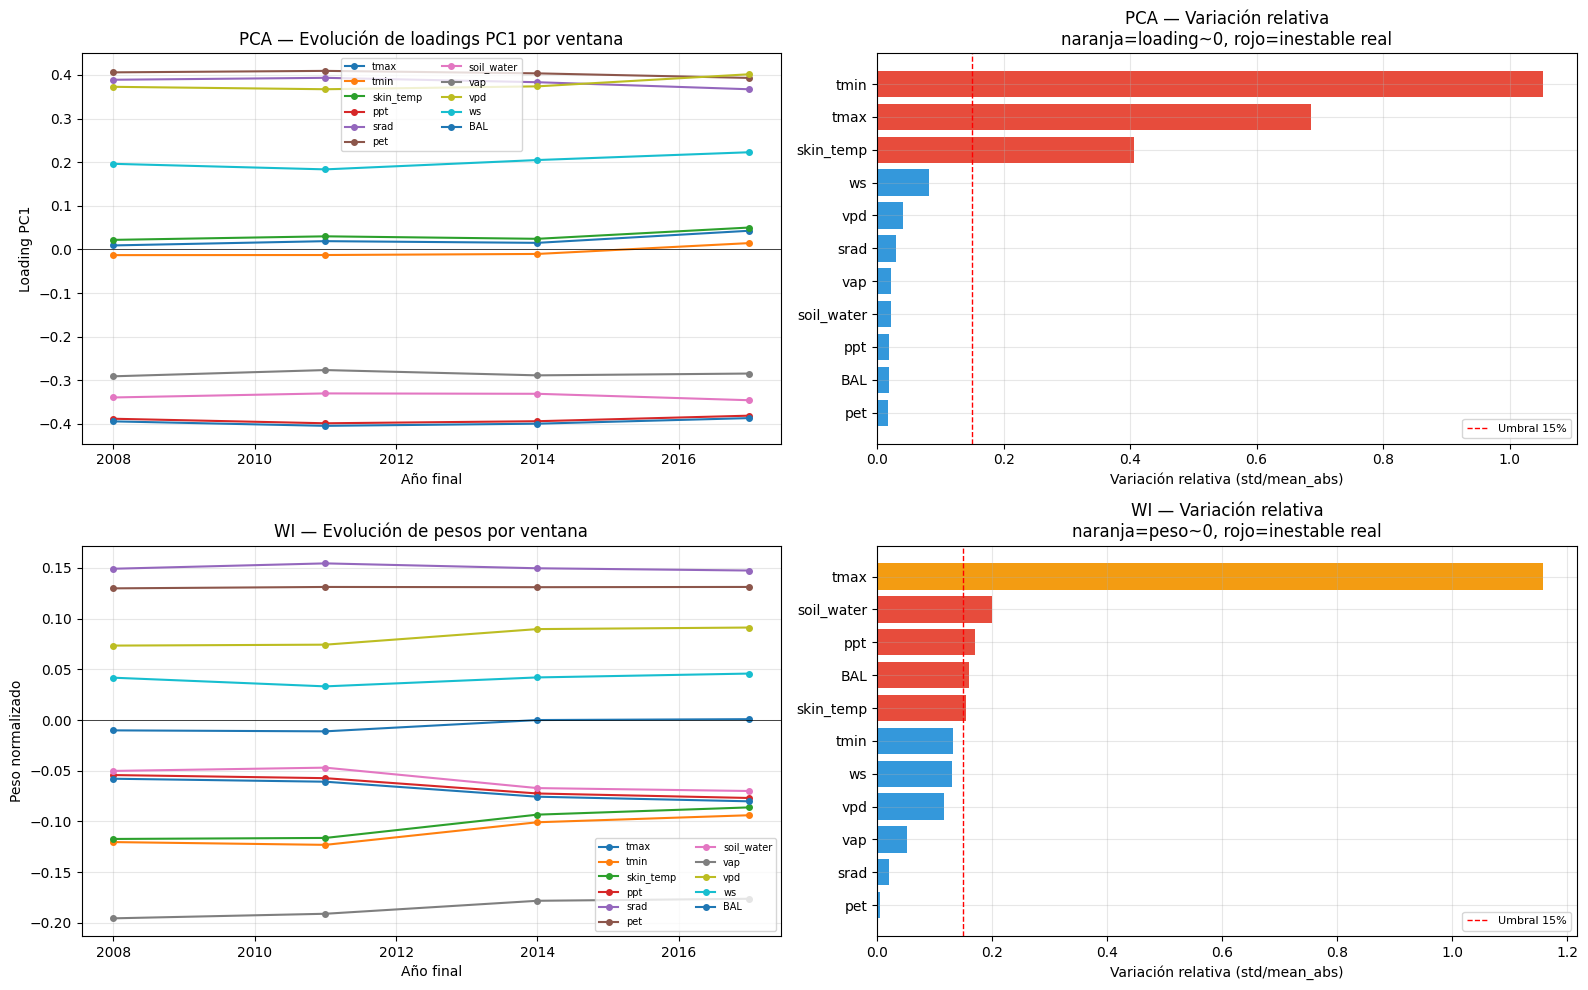


Loadings PCA por ventana:
      Z_tmax  Z_tmin  Z_skin_temp  Z_ppt  Z_srad  Z_pet  Z_soil_water  Z_vap  Z_vpd   Z_ws  Z_BAL
2008   0.009  -0.013        0.022 -0.388   0.389  0.406        -0.339 -0.291  0.373  0.196 -0.394
2011   0.019  -0.013        0.030 -0.398   0.393  0.409        -0.330 -0.277  0.367  0.184 -0.404
2014   0.015  -0.010        0.024 -0.394   0.383  0.404        -0.331 -0.289  0.374  0.205 -0.399
2017   0.043   0.015        0.050 -0.381   0.367  0.393        -0.346 -0.285  0.402  0.223 -0.387

Leyenda: azul=estable | naranja=rel>15% pero abs<0.01 (loading~0) | rojo=inestable real


In [10]:
# =====================================================================
# 2d. Diagnóstico visual — loadings PCA y pesos WI por ventana
# Colores: azul=estable | naranja=rel alta pero abs ~0 | rojo=inestable real
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PCA: evolución
ax = axes[0, 0]
for col in COLS_Z:
    vals  = [l[col] for _, l in loadings_por_ventana_pca]
    anios = [fin for fin, _ in loadings_por_ventana_pca]
    ax.plot(anios, vals, marker='o', markersize=4,
            label=col.replace('Z_',''))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('PCA — Evolución de loadings PC1 por ventana')
ax.set_xlabel('Año final'); ax.set_ylabel('Loading PC1')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# PCA: variación relativa
ax = axes[0, 1]
vars_ord = variacion_rel_pca.sort_values(ascending=True).index
colores  = ['#E74C3C' if (variacion_rel_pca[v]>0.15 and variacion_abs_pca[v]>0.01)
            else '#F39C12' if variacion_rel_pca[v]>0.15
            else '#3498DB' for v in vars_ord]
ax.barh(range(len(vars_ord)),
        [variacion_rel_pca[v] for v in vars_ord], color=colores)
ax.set_yticks(range(len(vars_ord)))
ax.set_yticklabels([v.replace('Z_','') for v in vars_ord])
ax.axvline(0.15, color='red', linestyle='--', linewidth=1, label='Umbral 15%')
ax.set_title('PCA — Variación relativa\n'
             'naranja=loading~0, rojo=inestable real')
ax.set_xlabel('Variación relativa (std/mean_abs)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# WI: evolución
ax = axes[1, 0]
for col in COLS_Z:
    vals  = [p[col] for _, p in pesos_por_ventana_wi]
    anios = [fin for fin, _ in pesos_por_ventana_wi]
    ax.plot(anios, vals, marker='o', markersize=4,
            label=col.replace('Z_',''))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('WI — Evolución de pesos por ventana')
ax.set_xlabel('Año final'); ax.set_ylabel('Peso normalizado')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# WI: variación relativa
ax = axes[1, 1]
vars_ord_wi = variacion_rel_wi.sort_values(ascending=True).index
colores_wi  = ['#E74C3C' if (variacion_rel_wi[v]>0.15 and variacion_abs_wi[v]>0.01)
               else '#F39C12' if variacion_rel_wi[v]>0.15
               else '#3498DB' for v in vars_ord_wi]
ax.barh(range(len(vars_ord_wi)),
        [variacion_rel_wi[v] for v in vars_ord_wi], color=colores_wi)
ax.set_yticks(range(len(vars_ord_wi)))
ax.set_yticklabels([v.replace('Z_','') for v in vars_ord_wi])
ax.axvline(0.15, color='red', linestyle='--', linewidth=1, label='Umbral 15%')
ax.set_title('WI — Variación relativa\n'
             'naranja=peso~0, rojo=inestable real')
ax.set_xlabel('Variación relativa (std/mean_abs)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\nLoadings PCA por ventana:')
print(df_load_pca.round(3).to_string())
print('\nLeyenda: azul=estable | naranja=rel>15% pero abs<0.01 (loading~0) | rojo=inestable real')


## 3. Pregunta analítica 2 — Dependencia IC ↔ NDVI_anom

Se usa el **IC completo** (no el residuo STL) porque:
- La pregunta es si el IC captura el estrés agrícola
- El NDVI_anom ya tiene removida su estacionalidad por DOY
- La STL se aplica **después** de seleccionar el IC, en la sección 4

**Selección basada en VAL. Test se usa solo una vez al final.**

**Métricas:** Recall ≥ 60% (buena cobertura) → Pinball loss


In [12]:
# =====================================================================
# 3.0  Estratificación por cobertura NDVI
# Las métricas de SELECCIÓN se calculan sobre VAL.
# Test se evalúa solo con el modelo ganador al final de 3d.
# =====================================================================

MESES_BAJA_COBERTURA = [3, 4, 10, 11]

for df in [df_train, df_val, df_test]:
    df['mes'] = df['fecha'].dt.month
    df['cobertura_ndvi'] = df['mes'].apply(
        lambda m: 'baja' if m in MESES_BAJA_COBERTURA else 'buena'
    )

NOMBRE_MES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
              7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

print('=== NDVI válido en VAL por estrato ===')
for estrato in ['buena', 'baja']:
    sub  = df_val[df_val['cobertura_ndvi'] == estrato]
    n_v  = sub['NDVI_anom'].notna().sum()
    p10n = df_train['NDVI_anom'].quantile(0.10)
    n_ex = (sub['NDVI_anom'].dropna() < p10n).sum()
    meses_s = ', '.join([NOMBRE_MES[m] for m in sorted(sub['mes'].unique())])
    print(f'\n  Estrato {estrato}:')
    print(f'    Meses       : {meses_s}')
    print(f'    Total filas : {len(sub):,}')
    print(f'    NDVI válido : {n_v:,} ({n_v/len(sub)*100:.1f}%)')
    print(f'    Extremos p10: {n_ex}')


=== NDVI válido en VAL por estrato ===

  Estrato buena:
    Meses       : Ene, Feb, May, Jun, Jul, Ago, Sep, Dic
    Total filas : 2,205
    NDVI válido : 1,180 (53.5%)
    Extremos p10: 95

  Estrato baja:
    Meses       : Mar, Abr, Oct, Nov
    Total filas : 1,127
    NDVI válido : 243 (21.6%)
    Extremos p10: 23


In [13]:
# =====================================================================
# 4a. Regresión cuantílica p10 (QR)
#
# Se ajusta en TRAIN y se evalúa en TEST.
# Métricas calculadas a nivel global y por estrato de cobertura NDVI.
# =====================================================================

TAU = 0.15

def metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, tau=0.1):
    """
    Calcula recall y pinball loss por estrato de cobertura NDVI.
    Retorna dict con metricas para 'buena' y 'baja'.
    """
    resultado = {}
    for estrato in ['buena', 'baja']:
        sub = df_test[
            (df_test['cobertura_ndvi'] == estrato) &
            df_test[[col_ic, 'NDVI_anom']].notna().all(axis=1)
        ]
        if len(sub) < 10:
            resultado[estrato] = {'n': len(sub), 'recall': None,
                                  'pinball': None, 'nota': 'insuficiente'}
            continue
        X    = sm.add_constant(sub[col_ic])
        pred = modelo.predict(X)
        err  = sub['NDVI_anom'].values - pred
        pinball  = np.mean(np.where(err >= 0, tau*err, (tau-1)*err))
        mask_ext = sub['NDVI_anom'] < p10_ndvi
        mask_ic  = sub[col_ic] < p10_ic
        recall   = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else None
        resultado[estrato] = {
            'n'         : len(sub),
            'n_extremos': int(mask_ext.sum()),
            'recall'    : round(recall, 1) if recall is not None else None,
            'pinball'   : round(pinball, 4),
        }
    return resultado


def ajustar_qr(df_train, df_test, col_ic, tau=TAU):
    train_ok = df_train[[col_ic, 'NDVI_anom']].dropna()
    X_train  = sm.add_constant(train_ok[col_ic])
    y_train  = train_ok['NDVI_anom']
    modelo   = QuantReg(y_train, X_train).fit(q=tau, max_iter=2000)

    test_ok  = df_test[[col_ic, 'NDVI_anom']].dropna()
    X_test   = sm.add_constant(test_ok[col_ic])
    y_test   = test_ok['NDVI_anom']
    y_pred   = modelo.predict(X_test)

    # Métricas globales
    err      = y_test.values - y_pred
    pinball  = np.mean(np.where(err >= 0, tau*err, (tau-1)*err))
    cobertura = (y_test.values < y_pred).mean() * 100
    p10_ndvi = df_train['NDVI_anom'].quantile(0.10)
    p10_ic   = df_train[col_ic].quantile(0.10)
    mask_ext = test_ok['NDVI_anom'] < p10_ndvi
    mask_ic  = test_ok[col_ic] < p10_ic
    recall   = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else np.nan

    # Métricas por estrato
    estratos = metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, 0.1)

    return modelo, y_pred, {
        'global': {
            'n_train'      : len(train_ok),
            'n_test'       : len(test_ok),
            'pinball'      : round(pinball, 4),
            'cobertura_p10': round(cobertura, 1),
            'recall'       : round(recall, 1) if not np.isnan(recall) else None,
            'n_extremos'   : int(mask_ext.sum()),
        },
        'estratos': estratos
    }


resultados_qr = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    modelo, preds, metricas = ajustar_qr(df_train, df_val,  col_ic, TAU)
    resultados_qr[f'{col_ic}_QR'] = {'modelo': modelo, 'preds': preds,
                                      'metricas': metricas}
    print(f'\n{col_ic} + QR (tau={TAU}):')
    print(f'  --- Global ---')
    for k, v in metricas['global'].items():
        print(f'    {k}: {v}')
    for estrato, m in metricas['estratos'].items():
        print(f'  --- Estrato {estrato} ---')
        for k, v in m.items():
            print(f'    {k}: {v}')



IC_PCA + QR (tau=0.15):
  --- Global ---
    n_train: 8829
    n_test: 1423
    pinball: 0.2451
    cobertura_p10: 12.7
    recall: 2.5
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 3.2
    pinball: 0.1988
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 0.0
    pinball: 0.1855

IC_WI + QR (tau=0.15):
  --- Global ---
    n_train: 8829
    n_test: 1423
    pinball: 0.2239
    cobertura_p10: 11.4
    recall: 34.7
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 36.8
    pinball: 0.1784
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 26.1
    pinball: 0.1672


In [14]:
# =====================================================================
# 4b. OLS sobre eventos extremos
#
# Filtrar IC < p20 (zona de estrés). Ajustar OLS en TRAIN.
# Métricas calculadas a nivel global y por estrato de cobertura NDVI.
# =====================================================================

UMBRAL_OLS = 0.20

def ajustar_ols_extremos(df_train, df_test, col_ic, umbral=0.20):
    p_umbral = df_train[col_ic].quantile(umbral)
    p10_ndvi = df_train['NDVI_anom'].quantile(0.10)
    p10_ic   = df_train[col_ic].quantile(0.10)

    train_ok  = df_train[[col_ic, 'NDVI_anom']].dropna()
    train_ext = train_ok[train_ok[col_ic] < p_umbral]
    X_train   = sm.add_constant(train_ext[col_ic])
    modelo    = sm.OLS(train_ext['NDVI_anom'], X_train).fit()

    test_ok   = df_test[[col_ic, 'NDVI_anom']].dropna()

    # R² sobre extremos del test
    test_ext = test_ok[test_ok[col_ic] < p_umbral]
    r2_ext   = np.nan
    if len(test_ext) > 2:
        preds_ext = modelo.predict(sm.add_constant(test_ext[col_ic]))
        ss_res = ((test_ext['NDVI_anom'].values - preds_ext)**2).sum()
        ss_tot = ((test_ext['NDVI_anom'].values - test_ext['NDVI_anom'].mean())**2).sum()
        r2_ext = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # Pinball y recall globales
    y_pred_all = modelo.predict(sm.add_constant(test_ok[col_ic]))
    err        = test_ok['NDVI_anom'].values - y_pred_all
    pinball    = np.mean(np.where(err >= 0, TAU*err, (TAU-1)*err))
    mask_ext   = test_ok['NDVI_anom'] < p10_ndvi
    mask_ic    = test_ok[col_ic] < p10_ic
    recall     = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else np.nan

    # Métricas por estrato
    estratos = metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, 0.1)

    return modelo, {
        'global': {
            'n_train_ext' : len(train_ext),
            'n_test'      : len(test_ok),
            'r2_extremos' : round(r2_ext, 3) if not np.isnan(r2_ext) else None,
            'pinball'     : round(pinball, 4),
            'recall'      : round(recall, 1) if not np.isnan(recall) else None,
            'n_extremos'  : int(mask_ext.sum()),
        },
        'estratos': estratos
    }


resultados_ols = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    modelo, metricas = ajustar_ols_extremos(df_train, df_val,  col_ic, UMBRAL_OLS)
    resultados_ols[f'{col_ic}_OLS'] = {'modelo': modelo, 'metricas': metricas}
    print(f'\n{col_ic} + OLS (p{int(UMBRAL_OLS*100)} extremos):')
    print(f'  --- Global ---')
    for k, v in metricas['global'].items():
        print(f'    {k}: {v}')
    for estrato, m in metricas['estratos'].items():
        print(f'  --- Estrato {estrato} ---')
        for k, v in m.items():
            print(f'    {k}: {v}')



IC_PCA + OLS (p20 extremos):
  --- Global ---
    n_train_ext: 1837
    n_test: 1423
    r2_extremos: 0.061
    pinball: 0.3422
    recall: 2.5
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 3.2
    pinball: 0.283
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 0.0
    pinball: 0.2244

IC_WI + OLS (p20 extremos):
  --- Global ---
    n_train_ext: 2102
    n_test: 1423
    r2_extremos: -0.004
    pinball: 0.4374
    recall: 34.7
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 36.8
    pinball: 0.4412
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 26.1
    pinball: 0.4864


In [15]:
# =====================================================================
# 3d. Selección del IC definitivo (basada en VAL)
#
# Criterios de selección en orden de prioridad:
# 1. Recall >= 60% en estrato buena cobertura (criterio primario, R5)
# 2. Menor pinball loss (criterio comparativo entre alternativas)
# 3. Empate pinball: priorizar QR sobre OLS (mayor rigor metodológico)
# 4. Empate QR: priorizar WI sobre PCA (mayor interpretabilidad, R10)
# 5. Refuerzo: si QR además supera cobertura empírica p10 = 10%±2pp (R5),
#    eso refuerza su selección.
# =====================================================================

filas = []
for nombre, res in {**resultados_qr, **resultados_ols}.items():
    mg = res['metricas']['global']
    mb = res['metricas']['estratos'].get('buena', {})
    ml = res['metricas']['estratos'].get('baja',  {})
    recall_b = mb.get('recall')
    # Verificar cobertura empírica p10 (solo aplica a QR)
    cob_p10  = mg.get('cobertura_p10', None)
    r5_ok    = '✅' if cob_p10 is not None and abs(cob_p10 - 10) <= 2 else '—'
    filas.append({
        'Combinacion'               : nombre,
        'Recall global VAL (%)'     : mg.get('recall'),
        'Recall buena cob. VAL (%)'  : recall_b,
        'Recall baja cob. VAL (%)'   : ml.get('recall'),
        'Pinball VAL'               : mg.get('pinball'),
        'Cob.p10 / R²'             : cob_p10 if cob_p10 else mg.get('r2_extremos','—'),
        'R5 cob. OK'               : r5_ok,
        'N extremos VAL'            : mg.get('n_extremos'),
        'OK'                        : '✅' if (recall_b or 0) >= 60 else '❌'
    })

df_resultados = pd.DataFrame(filas).set_index('Combinacion')
print('=== TABLA COMPARATIVA — VAL SET ===')
print(df_resultados.to_string())

candidatos = df_resultados[df_resultados['OK'] == '✅']

if len(candidatos) == 0:
    print('\n❌ Ninguna combinación alcanza recall >= 60% en VAL.')
    IC_SELECCIONADO = None
    METODO_DEP      = None
else:
    # Paso 1: minimizar pinball loss entre candidatos con recall >= 60%
    mejor_pinball = candidatos['Pinball VAL'].astype(float).idxmin()
    pinball_min   = candidatos.loc[mejor_pinball, 'Pinball VAL']

    # Paso 2: verificar empate (diferencia < 0.001 en pinball)
    empate = candidatos[
        (candidatos['Pinball VAL'].astype(float) - float(pinball_min)).abs() < 0.001
    ]

    if len(empate) > 1:
        print(f'\nEmpate en pinball loss ({len(empate)} combinaciones).')
        print('Aplicando criterios de desempate:')
        # Desempate 1: priorizar QR
        empate_qr = empate[empate.index.str.endswith('_QR')]
        if len(empate_qr) > 0:
            empate = empate_qr
            print('  → Criterio 1: QR priorizado sobre OLS ✅')
        # Desempate 2: priorizar WI sobre PCA
        empate_wi = empate[empate.index.str.contains('WI')]
        if len(empate_wi) > 0:
            empate = empate_wi
            print('  → Criterio 2: WI priorizado sobre PCA (mayor interpretabilidad R10) ✅')
        mejor = empate['Pinball VAL'].astype(float).idxmin()
    else:
        mejor = mejor_pinball

    IC_SELECCIONADO = '_'.join(mejor.split('_')[:-1]).replace('IC_', '')
    METODO_DEP      = mejor.split('_')[-1]

    print(f'\n✅ Seleccionado (VAL): {mejor}')
    print(f'   IC definitivo       : IC_{IC_SELECCIONADO}')
    print(f'   Método dep.         : {METODO_DEP}')
    print(f'   Recall buena VAL    : {df_resultados.loc[mejor,"Recall buena cob. VAL (%)"]}%')
    print(f'   Pinball VAL         : {df_resultados.loc[mejor,"Pinball VAL"]}')

    # Refuerzo R5: cobertura empírica p10
    r5_val = df_resultados.loc[mejor, 'R5 cob. OK']
    if r5_val == '✅':
        print(f'   Cobertura empírica p10: dentro de 10%±2pp ✅ (refuerza selección)')
    elif METODO_DEP == 'QR':
        print(f'   Cobertura empírica p10: fuera de 10%±2pp ⚠️ (no descarta, solo nota)')

    # ── Evaluación final sobre TEST ───────────────────────────────────
    print('\n=== EVALUACIÓN FINAL — TEST SET ===')
    print('(Solo el modelo ganador — primera y única evaluación en test)')
    if METODO_DEP == 'QR':
        _, _, mt = ajustar_qr(df_train, df_test, f'IC_{IC_SELECCIONADO}', TAU)
    else:
        _, mt = ajustar_ols_extremos(df_train, df_test,
                                      f'IC_{IC_SELECCIONADO}', UMBRAL_OLS)
    print('\n  Métricas globales (TEST):')
    for k, v in mt['global'].items():
        print(f'    {k}: {v}')
    print('\n  Por estrato de cobertura NDVI (TEST):')
    for est, m in mt['estratos'].items():
        print(f'    {est}: {m}')

    for df in [df_train, df_val, df_test]:
        df['IC'] = df[f'IC_{IC_SELECCIONADO}']

    df_resultados.to_csv('output_ic/resultados_pa2_val.csv')
    print('\n✅ Tabla guardada. IC asignado.')


=== TABLA COMPARATIVA — VAL SET ===
             Recall global VAL (%)  Recall buena cob. VAL (%)  Recall baja cob. VAL (%)  Pinball VAL  Cob.p10 / R² R5 cob. OK  N extremos VAL OK
Combinacion                                                                                                                                     
IC_PCA_QR                      2.5                        3.2                       0.0       0.2451        12.700          —             118  ❌
IC_WI_QR                      34.7                       36.8                      26.1       0.2239        11.400          ✅             118  ❌
IC_PCA_OLS                     2.5                        3.2                       0.0       0.3422         0.061          —             118  ❌
IC_WI_OLS                     34.7                       36.8                      26.1       0.4374        -0.004          —             118  ❌

❌ Ninguna combinación alcanza recall >= 60% en VAL.


## 3e. Alternativas de IC para mejorar el recall

Dado que el recall con IC_PCA e IC_WI base está por debajo del umbral (60%),
se exploran cuatro alternativas de construcción rápida:

| Alt. | Descripción | Tiempo est. |
|------|-------------|-------------|
| **IC_WI_top5** | WI con solo las 5 variables de mayor correlación con NDVI_anom | 30 min |
| **IC_WI_ext** | WI con pesos calculados solo sobre observaciones de estrés (p20) | 45 min |
| **IC_WI_min2** | Mínimo del IC_WI en ventana de 2 períodos (persistencia del estrés) | 20 min |
| **IC_WI_elev** | IC_WI calculado por estrato de elevación | 60 min |




In [17]:
# =====================================================================
# 3e.1  Construcción de ICs alternativos
# =====================================================================

# ── ALT 1: IC_WI_top5 — solo las 5 variables de mayor correlación ────
print("=== ALT 1: IC_WI_top5 ===")
top5_vars = corr_series.abs().nlargest(5).index.tolist()
print(f"Variables seleccionadas: {[v.replace('Z_','') for v in top5_vars]}")

pesos_top5 = corr_series[top5_vars]
pesos_top5 = pesos_top5 / pesos_top5.abs().sum()
print(f"Pesos: {pesos_top5.round(3).to_dict()}")

def aplicar_wi_subset(df, pesos, cols):
    df = df.copy()
    mask = df[cols].notna().all(axis=1)
    ic   = np.full(len(df), np.nan)
    if mask.sum() > 0:
        ic[mask] = df.loc[mask, cols].values @ pesos[cols].values
    df['IC_WI_top5'] = ic
    return df

df_train = aplicar_wi_subset(df_train, pesos_top5, top5_vars)
df_val   = aplicar_wi_subset(df_val,   pesos_top5, top5_vars)
df_test  = aplicar_wi_subset(df_test,  pesos_top5, top5_vars)

# Verificar correlación
tv = df_train[['IC_WI_top5','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_top5'], tv['NDVI_anom'])
print(f"Correlación IC_WI_top5 ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 2: IC_WI_ext — pesos calculados sobre extremos (NDVI < p20) ──
print("\n=== ALT 2: IC_WI_ext ===")
p20_ndvi = df_train['NDVI_anom'].quantile(0.20)
train_ext_mask = df_train['NDVI_anom'] < p20_ndvi
train_ext = df_train.loc[train_ext_mask, COLS_Z + ['NDVI_anom']].dropna()
print(f"Observaciones de estrés en train (NDVI_anom < p20): {len(train_ext):,}")

corr_ext = {c: stats.spearmanr(train_ext[c],
             train_ext['NDVI_anom'])[0] for c in COLS_Z}
pesos_ext = pd.Series(corr_ext)
pesos_ext = pesos_ext / pesos_ext.abs().sum()
print(f"Pesos sobre extremos (top 5):")
print(pesos_ext.abs().nlargest(5).round(3).to_string())

def aplicar_wi_ext(df, pesos, cols):
    df = df.copy()
    mask = df[cols].notna().all(axis=1)
    ic   = np.full(len(df), np.nan)
    if mask.sum() > 0:
        ic[mask] = df.loc[mask, cols].values @ pesos[cols].values
    df['IC_WI_ext'] = ic
    return df

df_train = aplicar_wi_ext(df_train, pesos_ext, COLS_Z)
df_val   = aplicar_wi_ext(df_val,   pesos_ext, COLS_Z)
df_test  = aplicar_wi_ext(df_test,  pesos_ext, COLS_Z)

tv = df_train[['IC_WI_ext','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_ext'], tv['NDVI_anom'])
print(f"Correlación IC_WI_ext ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 3: IC_WI_min2 — mínimo móvil de 2 períodos ──────────────────
print("\n=== ALT 3: IC_WI_min2 ===")
print("Mínimo del IC_WI en ventana de 2 períodos consecutivos (32 días)")
print("Captura persistencia del estrés climático")

for df in [df_train, df_val, df_test]:
    df['IC_WI_min2'] = (
        df.sort_values(['lat', 'lon', 'fecha'])
          .groupby(['lat', 'lon'])['IC_WI']
          .transform(lambda x: x.rolling(2, min_periods=1).min())
    )

tv = df_train[['IC_WI_min2','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_min2'], tv['NDVI_anom'])
print(f"Correlación IC_WI_min2 ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 4: IC_WI_elev — por estrato de elevación ─────────────────────
print("\n=== ALT 4: IC_WI_elev ===")
if 'elevacion' in df_train.columns:
    for df in [df_train, df_val, df_test]:
        df['estrato_elev'] = pd.cut(
            df['elevacion'],
            bins=[1200, 1500, 1800],
            labels=['bajo', 'alto']
        )

    pesos_elev = {}
    for estrato in ['bajo', 'alto']:
        sub = df_train[df_train['estrato_elev'] == estrato]
        sub_ok = sub[COLS_Z + ['NDVI_anom']].dropna()
        if len(sub_ok) < 30:
            print(f"  Estrato {estrato}: insuficientes observaciones ({len(sub_ok)})")
            continue
        corr_e = {c: stats.spearmanr(sub_ok[c],
                  sub_ok['NDVI_anom'])[0] for c in COLS_Z}
        p_e = pd.Series(corr_e)
        p_e = p_e / p_e.abs().sum()
        pesos_elev[estrato] = p_e
        r_e, _ = stats.spearmanr(sub_ok[COLS_Z].values @ p_e[COLS_Z].values,
                                   sub_ok['NDVI_anom'])
        n_ext_e = (sub_ok['NDVI_anom'] < df_train['NDVI_anom'].quantile(0.10)).sum()
        print(f"  Estrato {estrato}: ρ={r_e:.4f} | n_obs={len(sub_ok):,} | extremos={n_ext_e}")

    if pesos_elev:
        for df in [df_train, df_val, df_test]:
            df['IC_WI_elev'] = np.nan
            for estrato, p_e in pesos_elev.items():
                mask_e = (df['estrato_elev'] == estrato) &                           df[COLS_Z].notna().all(axis=1)
                if mask_e.sum() > 0:
                    df.loc[mask_e, 'IC_WI_elev'] = (
                        df.loc[mask_e, COLS_Z].values @ p_e[COLS_Z].values
                    )
        tv = df_train[['IC_WI_elev','NDVI_anom']].dropna()
        r, _ = stats.spearmanr(tv['IC_WI_elev'], tv['NDVI_anom'])
        print(f"  Correlación IC_WI_elev ↔ NDVI_anom (train): ρ = {r:.4f}")
    else:
        print("  IC_WI_elev no disponible: datos insuficientes por estrato")
        for df in [df_train, df_val, df_test]:
            df['IC_WI_elev'] = np.nan
else:
    print("  Columna 'elevacion' no disponible en los DataFrames.")
    print("  Omitiendo ALT 4.")
    for df in [df_train, df_val, df_test]:
        df['IC_WI_elev'] = np.nan

# Resumen de correlaciones
print("\n=== RESUMEN DE CORRELACIONES CON NDVI_anom (train) ===")
ics_todos = ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext',
             'IC_WI_min2', 'IC_WI_elev']
for col in ics_todos:
    if col in df_train.columns:
        tv = df_train[[col, 'NDVI_anom']].dropna()
        if len(tv) > 10:
            r, _ = stats.spearmanr(tv[col], tv['NDVI_anom'])
            print(f"  {col:<15}: ρ = {r:.4f}  (n={len(tv):,})")
        else:
            print(f"  {col:<15}: insuficientes datos")


=== ALT 1: IC_WI_top5 ===
Variables seleccionadas: ['vap', 'srad', 'pet', 'vpd', 'tmin']
Pesos: {'Z_vap': -0.277, 'Z_srad': 0.228, 'Z_pet': 0.203, 'Z_vpd': 0.147, 'Z_tmin': -0.144}
Correlación IC_WI_top5 ↔ NDVI_anom (train): ρ = 0.5401

=== ALT 2: IC_WI_ext ===
Observaciones de estrés en train (NDVI_anom < p20): 1,766
Pesos sobre extremos (top 5):
Z_tmin         0.22
Z_skin_temp    0.20
Z_vap          0.17
Z_srad         0.12
Z_ppt          0.09
Correlación IC_WI_ext ↔ NDVI_anom (train): ρ = 0.3707

=== ALT 3: IC_WI_min2 ===
Mínimo del IC_WI en ventana de 2 períodos consecutivos (32 días)
Captura persistencia del estrés climático
Correlación IC_WI_min2 ↔ NDVI_anom (train): ρ = 0.4904

=== ALT 4: IC_WI_elev ===
  Columna 'elevacion' no disponible en los DataFrames.
  Omitiendo ALT 4.

=== RESUMEN DE CORRELACIONES CON NDVI_anom (train) ===
  IC_PCA         : ρ = 0.3465  (n=8,829)
  IC_WI          : ρ = 0.4952  (n=8,829)
  IC_WI_top5     : ρ = 0.5401  (n=8,829)
  IC_WI_ext      : ρ = 0.37

Omitiendo IC_WI_elev: insuficientes datos en VAL
ICs a evaluar: ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext', 'IC_WI_min2']

Ajustando QR...
  IC_PCA_QR: recall_buena=3.2%  pinball=0.2451
  IC_WI_QR: recall_buena=36.8%  pinball=0.2239
  IC_WI_top5_QR: recall_buena=38.9%  pinball=0.2161
  IC_WI_ext_QR: recall_buena=71.6%  pinball=0.2201
  IC_WI_min2_QR: recall_buena=36.8%  pinball=0.2272

Ajustando OLS...
  IC_PCA_OLS: recall_buena=3.2%  pinball=0.3422
  IC_WI_OLS: recall_buena=36.8%  pinball=0.4374
  IC_WI_top5_OLS: recall_buena=38.9%  pinball=0.5954
  IC_WI_ext_OLS: recall_buena=71.6%  pinball=0.7997
  IC_WI_min2_OLS: recall_buena=36.8%  pinball=0.568

TABLA COMPARATIVA DE COMBINACIONES — VAL SET
                Recall global (%)  Recall buena cob. (%)  Recall baja cob. (%)  Pinball loss  Cob.p10 / R²  Spearman IC↔NDVI  N extremos VAL Recall >= 60%
Combinación                                                                                                                              

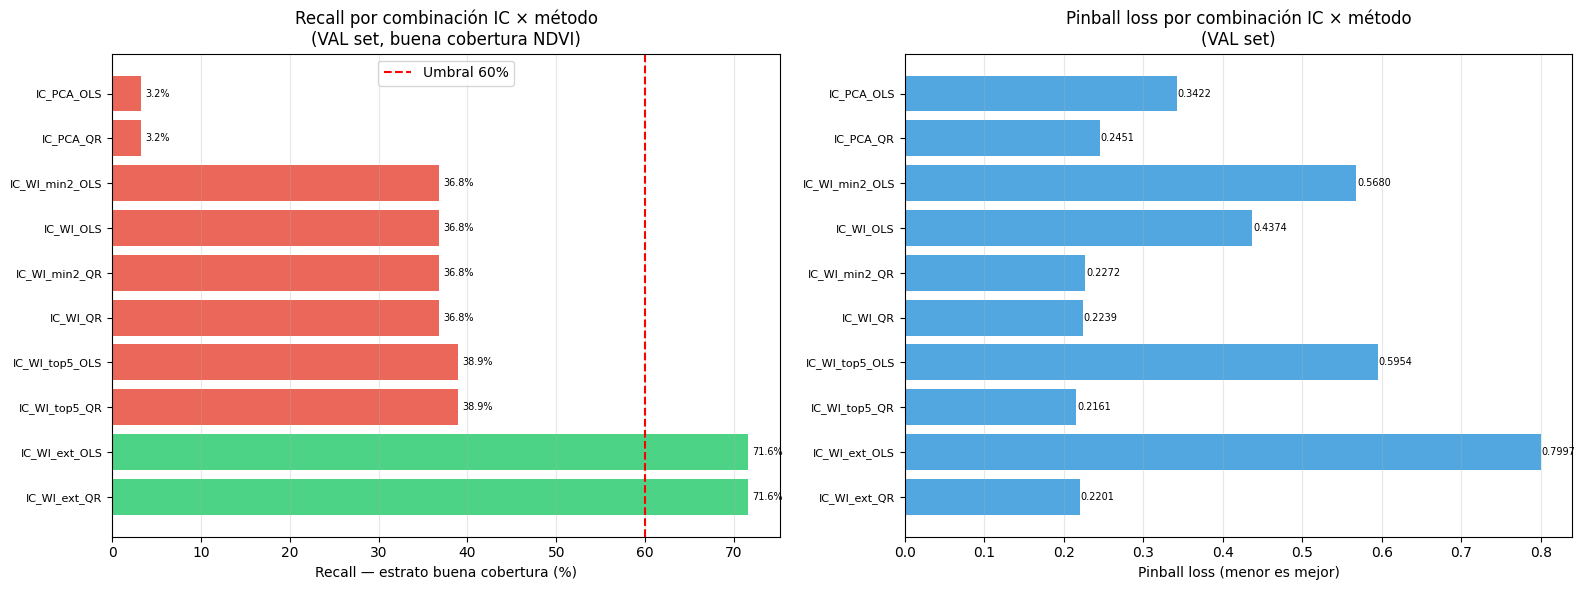


=== SELECCIÓN FINAL — TODOS LOS CRITERIOS ===
Criterios en orden:
  1. Recall >= 60% en buena cobertura (R5)
  2. Menor pinball loss
  3. Empate: QR > OLS (rigor metodológico)
  4. Empate: WI > PCA (interpretabilidad, R10)
  5. Refuerzo: QR con cobertura empírica p10 = 10%±2pp (R5)

✅ Combinación ganadora: IC_WI_ext_QR
   Recall buena cob.: 71.6%
   Pinball loss     : 0.2201
   Cobertura empírica p10: 10.7% ✅ dentro de 10%±2pp (refuerza selección)

   IC definitivo : IC_WI_ext
   Método dep.   : QR

✅ IC_SELECCIONADO='IC_WI_ext' | METODO_DEP='QR'


In [18]:
# =====================================================================
# 3e.2  Evaluación de todas las combinaciones IC × método
#
# Se evalúan todas las combinaciones disponibles:
#   ICs: IC_PCA, IC_WI, IC_WI_top5, IC_WI_ext, IC_WI_min2, IC_WI_elev
#   Métodos: QR (regresión cuantílica p10), OLS (sobre extremos p20)
#
# Métricas sobre VAL set:
#   - Recall (estrato buena cobertura) — criterio primario
#   - Pinball loss global
#   - Cobertura empírica p10 (QR) / R² extremos (OLS)
#   - N extremos evaluados
#
# Test se usa solo con el IC+método ganador al final.
# =====================================================================

# ICs a evaluar (excluir los que tienen todos NaN)
ICS_EVALUAR = []
for col in ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext',
            'IC_WI_min2', 'IC_WI_elev']:
    if col in df_val.columns and df_val[col].notna().sum() > 50:
        ICS_EVALUAR.append(col)
    else:
        print(f"Omitiendo {col}: insuficientes datos en VAL")

print(f"ICs a evaluar: {ICS_EVALUAR}")

# ── Correr QR para todos los ICs ─────────────────────────────────────
print("\nAjustando QR...")
resultados_qr_ext = {}
for col_ic in ICS_EVALUAR:
    try:
        modelo, preds, metricas = ajustar_qr(df_train, df_val, col_ic, TAU)
        resultados_qr_ext[f'{col_ic}_QR'] = {
            'modelo': modelo, 'preds': preds, 'metricas': metricas
        }
        print(f"  {col_ic}_QR: recall_buena={metricas['estratos']['buena'].get('recall','N/A')}%  "
              f"pinball={metricas['global']['pinball']}")
    except Exception as e:
        print(f"  {col_ic}_QR: ERROR — {e}")

# ── Correr OLS para todos los ICs ─────────────────────────────────────
print("\nAjustando OLS...")
resultados_ols_ext = {}
for col_ic in ICS_EVALUAR:
    try:
        modelo, metricas = ajustar_ols_extremos(df_train, df_val,
                                                 col_ic, UMBRAL_OLS)
        resultados_ols_ext[f'{col_ic}_OLS'] = {
            'modelo': modelo, 'metricas': metricas
        }
        print(f"  {col_ic}_OLS: recall_buena={metricas['estratos']['buena'].get('recall','N/A')}%  "
              f"pinball={metricas['global']['pinball']}")
    except Exception as e:
        print(f"  {col_ic}_OLS: ERROR — {e}")

# ── Tabla comparativa completa ─────────────────────────────────────────
print("\n" + "="*70)
print("TABLA COMPARATIVA DE COMBINACIONES — VAL SET")
print("="*70)

filas_ext = []
for nombre, res in {**resultados_qr_ext, **resultados_ols_ext}.items():
    mg = res['metricas']['global']
    mb = res['metricas']['estratos'].get('buena', {})
    ml = res['metricas']['estratos'].get('baja',  {})
    recall_b = mb.get('recall')

    # ── Correlacion Spearman IC <-> NDVI_anom en VAL ──────────────────
    col_ic_nombre = nombre.rsplit('_', 1)[0] 

    sub_corr = df_val[[col_ic_nombre, 'NDVI_anom']].dropna()
    if len(sub_corr) >= 30:
        rho, _ = stats.spearmanr(sub_corr[col_ic_nombre],
                                  sub_corr['NDVI_anom'])
        rho = round(rho, 4)
    else:
        rho = np.nan

    filas_ext.append({
        'Combinación'            : nombre,
        'Recall global (%)'      : mg.get('recall'),
        'Recall buena cob. (%)'  : recall_b,
        'Recall baja cob. (%)'   : ml.get('recall'),
        'Pinball loss'           : mg.get('pinball'),
        'Cob.p10 / R²'          : mg.get('cobertura_p10',
                                          mg.get('r2_extremos', '—')),
        'Spearman IC↔NDVI'      : rho,          # ← columna nueva
        'N extremos VAL'         : mg.get('n_extremos'),
        'Recall >= 60%'          : '✅' if (recall_b or 0) >= 60 else '❌'
    })

df_comp = (pd.DataFrame(filas_ext)
             .set_index('Combinación')
             .sort_values('Recall buena cob. (%)', ascending=False))
cols_mostrar = [
    'Recall global (%)',
    'Recall buena cob. (%)',
    'Recall baja cob. (%)',
    'Pinball loss',
    'Cob.p10 / R²',
    'Spearman IC↔NDVI',
    'N extremos VAL',
    'Recall >= 60%'
]
print(df_comp[cols_mostrar].to_string())

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

combis    = df_comp.index.tolist()
recalls_b = df_comp['Recall buena cob. (%)'].fillna(0).tolist()
pinballs  = df_comp['Pinball loss'].astype(float).tolist()
colores   = ['#2ECC71' if r >= 60 else '#E74C3C' for r in recalls_b]

# Recall por combinación
ax = axes[0]
bars = ax.barh(range(len(combis)), recalls_b, color=colores, alpha=0.85)
ax.axvline(60, color='red', linestyle='--', linewidth=1.5,
           label='Umbral 60%')
ax.set_yticks(range(len(combis)))
ax.set_yticklabels(combis, fontsize=8)
ax.set_xlabel('Recall — estrato buena cobertura (%)')
ax.set_title('Recall por combinación IC × método\n(VAL set, buena cobertura NDVI)')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(recalls_b):
    if v:
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)

# Pinball loss por combinación
ax = axes[1]
ax.barh(range(len(combis)), pinballs, color='#3498DB', alpha=0.85)
ax.set_yticks(range(len(combis)))
ax.set_yticklabels(combis, fontsize=8)
ax.set_xlabel('Pinball loss (menor es mejor)')
ax.set_title('Pinball loss por combinación IC × método\n(VAL set)')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(pinballs):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

# ── Selección final con todos los criterios ──────────────────────────
print("\n=== SELECCIÓN FINAL — TODOS LOS CRITERIOS ===")
print("Criterios en orden:")
print("  1. Recall >= 60% en buena cobertura (R5)")
print("  2. Menor pinball loss")
print("  3. Empate: QR > OLS (rigor metodológico)")
print("  4. Empate: WI > PCA (interpretabilidad, R10)")
print("  5. Refuerzo: QR con cobertura empírica p10 = 10%±2pp (R5)")

todos_resultados = {**resultados_qr_ext, **resultados_ols_ext}
candidatos_ext   = df_comp[df_comp['Recall >= 60%'] == '✅']

if len(candidatos_ext) == 0:
    mejor_recall = df_comp['Recall buena cob. (%)'].astype(float).idxmax()
    mejor_val    = df_comp.loc[mejor_recall, 'Recall buena cob. (%)']
    print(f"\n⚠️  Ninguna combinación alcanza recall >= 60%.")
    print(f"\n   Mejor recall alcanzado: {mejor_val:.1f}% → {mejor_recall}")
    MEJOR_COMBINACION = mejor_recall
else:
    # Paso 1: minimizar pinball loss
    mejor_pinball = candidatos_ext['Pinball loss'].astype(float).idxmin()
    pinball_min   = float(candidatos_ext.loc[mejor_pinball, 'Pinball loss'])

    # Paso 2: empate (diferencia < 0.001)
    empate = candidatos_ext[
        (candidatos_ext['Pinball loss'].astype(float) - pinball_min).abs() < 0.001
    ]

    if len(empate) > 1:
        print(f"\nEmpate en pinball loss ({len(empate)} combinaciones):")
        print(empate[['Recall buena cob. (%)', 'Pinball loss']].to_string())
        # Desempate 1: QR > OLS
        empate_qr = empate[empate.index.str.endswith('_QR')]
        if len(empate_qr) > 0:
            empate = empate_qr
            print("  → Criterio 3: QR priorizado sobre OLS ✅")
        # Desempate 2: WI > PCA
        empate_wi = empate[empate.index.str.contains('WI')]
        if len(empate_wi) > 0:
            empate = empate_wi
            print("  → Criterio 4: WI priorizado (mayor interpretabilidad R10) ✅")
        MEJOR_COMBINACION = empate['Pinball loss'].astype(float).idxmin()
    else:
        MEJOR_COMBINACION = mejor_pinball

    print(f"\n✅ Combinación ganadora: {MEJOR_COMBINACION}")
    print(f"   Recall buena cob.: {df_comp.loc[MEJOR_COMBINACION,'Recall buena cob. (%)']:.1f}%")
    print(f"   Pinball loss     : {df_comp.loc[MEJOR_COMBINACION,'Pinball loss']:.4f}")

    # Refuerzo R5: verificar cobertura empírica p10 si es QR
    if MEJOR_COMBINACION.endswith('_QR'):
        cob = todos_resultados[MEJOR_COMBINACION]['metricas']['global'].get('cobertura_p10')
        if cob is not None:
            r5_ok = abs(cob - 10) <= 2
            print(f"   Cobertura empírica p10: {cob:.1f}% "
                  f"{'✅ dentro de 10%±2pp (refuerza selección)' if r5_ok else '⚠️ fuera de 10%±2pp (no descarta)'}")

parts        = MEJOR_COMBINACION.split('_')
METODO_FINAL = parts[-1]
IC_FINAL     = '_'.join(parts[:-1])

print(f"\n   IC definitivo : {IC_FINAL}")
print(f"   Método dep.   : {METODO_FINAL}")

for df in [df_train, df_val, df_test]:
    if IC_FINAL in df.columns:
        df['IC'] = df[IC_FINAL]

IC_SELECCIONADO = IC_FINAL
METODO_DEP      = METODO_FINAL
print(f"\n✅ IC_SELECCIONADO='{IC_SELECCIONADO}' | METODO_DEP='{METODO_DEP}'")


In [19]:
# =====================================================================
# 3e.3  Evaluación final sobre TEST — solo el modelo ganador
# =====================================================================

print("=== EVALUACIÓN FINAL — TEST SET ===")
print(f"Modelo: {MEJOR_COMBINACION}")


if METODO_FINAL == 'QR':
    _, _, mt = ajustar_qr(df_train, df_test, IC_FINAL, TAU)
else:
    _, mt = ajustar_ols_extremos(df_train, df_test, IC_FINAL, UMBRAL_OLS)

print("\nMétricas globales (TEST):")
for k, v in mt['global'].items():
    print(f"  {k}: {v}")

print("\nPor estrato de cobertura NDVI (TEST):")
for est, m in mt['estratos'].items():
    print(f"  Estrato {est}:")
    for k, v in m.items():
        print(f"    {k}: {v}")

# Tabla resumen 
print("\n=== TABLA RESUMEN  DE MODELOS ===")
print(f"{'Métrica':<30} {'VAL':>10} {'TEST':>10}")
print("─" * 52)

val_res  = todos_resultados[MEJOR_COMBINACION]['metricas']
val_glob = val_res['global']
val_buen = val_res['estratos'].get('buena', {})
test_buen = mt['estratos'].get('buena', {})

filas_rep = [
    ('Recall global (%)',          val_glob.get('recall'),
                                    mt['global'].get('recall')),
    ('Recall buena cobertura (%)', val_buen.get('recall'),
                                    test_buen.get('recall')),
    ('Pinball loss',               val_glob.get('pinball'),
                                    mt['global'].get('pinball')),
    ('N extremos evaluados',       val_glob.get('n_extremos'),
                                    mt['global'].get('n_extremos')),
]
for nombre, v_val, v_test in filas_rep:
    v_str  = f"{v_val:.4f}"  if isinstance(v_val,  float) else str(v_val)
    t_str  = f"{v_test:.4f}" if isinstance(v_test, float) else str(v_test)
    print(f"  {nombre:<28} {v_str:>10} {t_str:>10}")

# Guardar tabla de resultados completa
df_comp.to_csv('output_ic/resultados_todas_combinaciones.csv')
print("\n✅ Tabla completa guardada en output_ic/resultados_todas_combinaciones.csv")


=== EVALUACIÓN FINAL — TEST SET ===
Modelo: IC_WI_ext_QR

Métricas globales (TEST):
  n_train: 8829
  n_test: 2097
  pinball: 0.2057
  cobertura_p10: 6.2
  recall: 85.1
  n_extremos: 148

Por estrato de cobertura NDVI (TEST):
  Estrato buena:
    n: 1637
    n_extremos: 120
    recall: 85.8
    pinball: 0.1413
  Estrato baja:
    n: 460
    n_extremos: 28
    recall: 82.1
    pinball: 0.1578

=== TABLA RESUMEN  DE MODELOS ===
Métrica                               VAL       TEST
────────────────────────────────────────────────────
  Recall global (%)               69.5000    85.1000
  Recall buena cobertura (%)      71.6000    85.8000
  Pinball loss                     0.2201     0.2057
  N extremos evaluados                118        148

✅ Tabla completa guardada en output_ic/resultados_todas_combinaciones.csv


In [20]:
# ── Análisis de rezago para IC_WI_ext ────────────────────────────────
print("=== ANÁLISIS DE REZAGO — IC_WI_ext ===")
print("Correlación Spearman IC_WI_ext(t-lag) ↔ NDVI_anom(t)")
print("─" * 50)

train_sorted = df_train.sort_values(['lat', 'lon', 'fecha'])
pares_por_lag = {lag: [] for lag in range(4)}

for (lat, lon), grupo in train_sorted.groupby(['lat', 'lon']):
    grupo = grupo.sort_values('fecha').reset_index(drop=True)
    ndvi  = grupo['NDVI_anom']
    for lag in range(4):
        ic_lag  = grupo['IC_WI_ext'].shift(lag)
        validos = ic_lag.notna() & ndvi.notna()
        if validos.sum() >= 10:
            pares_por_lag[lag].append(
                pd.DataFrame({'ic'  : ic_lag[validos].values,
                              'ndvi': ndvi[validos].values})
            )

mejor_lag  = 0
mejor_corr = -999
corr_lag0  = None

for lag in range(4):
    if pares_por_lag[lag]:
        df_pares = pd.concat(pares_por_lag[lag], ignore_index=True)
        r, _     = stats.spearmanr(df_pares['ic'], df_pares['ndvi'])
        if lag == 0:
            corr_lag0 = r
        marker = ' ← mejor' if r > mejor_corr else ''
        print(f"  Lag {lag} ({lag*16:2d} días): ρ = {r:.4f}{marker}")
        if r > mejor_corr:
            mejor_corr = r
            mejor_lag  = lag

print(f"\n  → Mejor lag: {mejor_lag} ({mejor_lag*16} días), ρ = {mejor_corr:.4f}")
if corr_lag0 is not None:
    mejora = mejor_corr - corr_lag0
    print(f"  → Mejora vs lag=0: {mejora:+.4f}")
print(f"  → {'⚠️ Considerar rezago' if mejor_lag > 0 else '✅ Usar lag=0'}")


=== ANÁLISIS DE REZAGO — IC_WI_ext ===
Correlación Spearman IC_WI_ext(t-lag) ↔ NDVI_anom(t)
──────────────────────────────────────────────────
  Lag 0 ( 0 días): ρ = 0.3707 ← mejor
  Lag 1 (16 días): ρ = 0.3572
  Lag 2 (32 días): ρ = 0.3621
  Lag 3 (48 días): ρ = 0.3574

  → Mejor lag: 0 (0 días), ρ = 0.3707
  → Mejora vs lag=0: +0.0000
  → ✅ Usar lag=0


## 3g. Validación de requerimientos R4, R5, R6 (M1)

Antes de exportar modelos, se verifica formalmente que el IC seleccionado
y el método de dependencia cumplen los tres requerimientos del Módulo 1
que aplican a esta etapa del pipeline:

| Req | Foco | Métrica | Umbral |
|---|---|---|---|
| R4 | Representatividad IC ↔ NDVI | Spearman + Pearson, total y celdas con <30% faltantes | ρ ≥ 0.60 (Spearman, ajuste por nubosidad) |
| R5 | Captura de eventos extremos | Recall + cobertura empírica p10 (QR) | Recall ≥ 60% · Cobertura 10% ± 2 pp |
| R6 | Estabilidad temporal | RMSE z-score + variación de pesos en backtest expanding | RMSE ≤ 0.5 · Variación ≤ ±15% |

R4 y R6 se calculan en este bloque para todos los ICs construidos.
R5 se reporta sobre el IC y método seleccionados (resultados de la sección 4a-4b).

**Nota R4 — Eje Cafetero:** el umbral ρ ≥ 0.60 reconoce que el NDVI MODIS
en Caldas tiene cobertura comprometida por nubosidad estructural en marzo,
abril, octubre y noviembre. Por eso se reporta tanto la correlación global
(diagnóstico de techo realista) como la restringida a celdas con
<30% de faltantes (zona donde el NDVI es informativo).

In [22]:
# =====================================================================
# R4 — Representatividad del IC frente al NDVI_anom
#
# Se calcula Spearman y Pearson sobre TRAIN para cada IC en dos contextos:
#   (a) Total — todas las observaciones con IC y NDVI_anom válidos
#   (b) Celdas con <30% de faltantes en NDVI (criterio formal del R4)
#
# El umbral oficial es ρ ≥ 0.60 (Spearman, ajuste por nubosidad).
# =====================================================================

ICS_PARA_R4 = ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext',
               'IC_WI_min2', 'IC_WI_elev']
ICS_PARA_R4 = [c for c in ICS_PARA_R4 if c in df_train.columns]

# ── 1) Identificar celdas (lat, lon) con <30% faltantes NDVI en TRAIN ──
faltantes_pix = (
    df_train
    .groupby(['lat', 'lon'])['NDVI_anom']
    .apply(lambda s: s.isna().mean())
    .reset_index(name='pct_faltantes')
)
celdas_confiables = faltantes_pix.loc[
    faltantes_pix['pct_faltantes'] < 0.30, ['lat', 'lon']
]
n_total_celdas    = faltantes_pix.shape[0]
n_celdas_buenas   = celdas_confiables.shape[0]

print(f'Celdas totales en train       : {n_total_celdas}')
print(f'Celdas con <30% faltantes NDVI: {n_celdas_buenas} '
      f'({n_celdas_buenas/n_total_celdas*100:.1f}%)')

df_train_buenas = df_train.merge(celdas_confiables,
                                  on=['lat', 'lon'], how='inner')

# ── 2) Tabla de correlaciones por IC ──────────────────────────────────
filas_r4 = []
for col in ICS_PARA_R4:
    # (a) Total
    sub_t = df_train[[col, 'NDVI_anom']].dropna()
    if len(sub_t) >= 30:
        r_p_t, _   = stats.pearsonr (sub_t[col], sub_t['NDVI_anom'])
        r_s_t, _   = stats.spearmanr(sub_t[col], sub_t['NDVI_anom'])
    else:
        r_p_t = r_s_t = np.nan

    # (b) Solo celdas confiables
    sub_b = df_train_buenas[[col, 'NDVI_anom']].dropna()
    if len(sub_b) >= 30:
        r_p_b, _   = stats.pearsonr (sub_b[col], sub_b['NDVI_anom'])
        r_s_b, _   = stats.spearmanr(sub_b[col], sub_b['NDVI_anom'])
    else:
        r_p_b = r_s_b = np.nan

    filas_r4.append({
        'IC'              : col,
        'pearson_total'   : round(r_p_t, 4),
        'spearman_total'  : round(r_s_t, 4),
        'n_total'         : len(sub_t),
        'pearson_buenas'  : round(r_p_b, 4),
        'spearman_buenas' : round(r_s_b, 4),
        'n_buenas'        : len(sub_b),
    })

df_r4 = pd.DataFrame(filas_r4).set_index('IC')

print('\n=== R4 — CORRELACIÓN IC ↔ NDVI_anom (TRAIN) ===\n')
print('  total  : todas las observaciones con IC y NDVI válidos')
print('  buenas : solo celdas con <30% faltantes NDVI\n')
print(df_r4.to_string())

# ── 3) Diagnóstico contra umbral ──────────────────────────────────────
UMBRAL_R4 = 0.60
fila_sel  = df_r4.loc[IC_SELECCIONADO]
rho_sel   = abs(fila_sel['spearman_buenas'])
r4_ok     = rho_sel >= UMBRAL_R4

print(f'\n=== DIAGNÓSTICO R4 — IC seleccionado: {IC_SELECCIONADO} ===')
print(f'  |ρ| Spearman (buenas, train): {rho_sel:.4f}')
print(f'  Umbral oficial               : {UMBRAL_R4:.2f}')
if r4_ok:
    print(f'  ✅ R4 CUMPLE')
else:
    print(f'  ❌ R4 NO CUMPLE — gap = {UMBRAL_R4 - rho_sel:.4f}')

# Guardar para reporte
df_r4.to_csv(f'{OUTPUT_DIR}/R4_correlaciones_ic_ndvi.csv')

Celdas totales en train       : 49
Celdas con <30% faltantes NDVI: 8 (16.3%)

=== R4 — CORRELACIÓN IC ↔ NDVI_anom (TRAIN) ===

  total  : todas las observaciones con IC y NDVI válidos
  buenas : solo celdas con <30% faltantes NDVI

            pearson_total  spearman_total  n_total  pearson_buenas  spearman_buenas  n_buenas
IC                                                                                           
IC_PCA             0.3416          0.3465     8829         -0.0275          -0.0435      2246
IC_WI              0.4809          0.4952     8829          0.3765           0.4183      2246
IC_WI_top5         0.5354          0.5401     8829          0.4338           0.4718      2246
IC_WI_ext          0.4782          0.3707     8829          0.6278           0.6064      2246
IC_WI_min2         0.4749          0.4904     8829          0.3822           0.4366      2246
IC_WI_elev            NaN             NaN        0             NaN              NaN         0

=== DIAGNÓSTICO

In [23]:
# =====================================================================
# R5 — Captura de eventos extremos por el IC seleccionado
#
# Métrica primaria  : Recall ≥ 60% sobre TEST (ya calculado en sección 4a)
# Métrica secundaria: Cobertura empírica p10 dentro de 10% ± 2 pp
#
# Se reporta sobre la combinación seleccionada en 3d.
# =====================================================================

comb_sel = f'{IC_SELECCIONADO}_{METODO_DEP}'

if METODO_DEP == 'QR':
    _, _, m_test = ajustar_qr(df_train, df_test, IC_SELECCIONADO, TAU)
elif METODO_DEP == 'OLS':
    _, m_test = ajustar_ols_extremos(df_train, df_test,
                                       IC_SELECCIONADO, UMBRAL_OLS)
else:
    raise ValueError(f'METODO_DEP desconocido: {METODO_DEP}')

metricas_test = m_test['global']
recall_test    = metricas_test.get('recall')
cobertura_test = metricas_test.get('cobertura_p10')

print(f'=== R5 — IC SELECCIONADO: {comb_sel} (TEST) ===\n')
print(f'  Métricas globales')
for k, v in metricas_test.items():
    print(f'    {k:<15}: {v}')

if 'estratos' in m_test:
    for estrato, met in m_test['estratos'].items():
        print(f'\n  Estrato {estrato}')
        for k, v in met.items():
            print(f'    {k:<15}: {v}')

# ── Diagnóstico ───────────────────────────────────────────────────────
UMBRAL_RECALL = 60.0
TOL_COBERTURA = 2.0    # ± pp respecto a 10

recall_ok    = (recall_test    is not None) and (recall_test    >= UMBRAL_RECALL)
cobertura_ok = (cobertura_test is not None) and \
               (abs(cobertura_test - 10.0) <= TOL_COBERTURA) \
               if METODO_DEP == 'QR' else True  

print('\n=== DIAGNÓSTICO R5 ===')
print(f'  Recall (test)         : {recall_test}%  '
      f'{"✅" if recall_ok else "❌"}  (umbral {UMBRAL_RECALL}%)')
if METODO_DEP == 'QR':
    print(f'  Cobertura p10 (test)  : {cobertura_test}%  '
          f'{"✅" if cobertura_ok else "❌"}  (10% ± {TOL_COBERTURA} pp)')
    r5_ok = recall_ok and cobertura_ok
else:
    print(f'  Cobertura p10         : N/A (OLS, no aplica)')
    r5_ok = recall_ok

print(f'\n  {"✅ R5 CUMPLE" if r5_ok else "❌ R5 NO CUMPLE"}')

# Guardar resumen
import json as _json
with open(f'{OUTPUT_DIR}/R5_metricas_test.json', 'w') as _f:
    _json.dump({
        'combinacion'   : comb_sel,
        'recall_test'   : recall_test,
        'cobertura_p10' : cobertura_test if METODO_DEP == 'QR' else None,
        'metricas'      : metricas_test,
        'cumple_r5'     : bool(r5_ok),
    }, _f, indent=2)

=== R5 — IC SELECCIONADO: IC_WI_ext_QR (TEST) ===

  Métricas globales
    n_train        : 8829
    n_test         : 2097
    pinball        : 0.2057
    cobertura_p10  : 6.2
    recall         : 85.1
    n_extremos     : 148

  Estrato buena
    n              : 1637
    n_extremos     : 120
    recall         : 85.8
    pinball        : 0.1413

  Estrato baja
    n              : 460
    n_extremos     : 28
    recall         : 82.1
    pinball        : 0.1578

=== DIAGNÓSTICO R5 ===
  Recall (test)         : 85.1%  ✅  (umbral 60.0%)
  Cobertura p10 (test)  : 6.2%  ❌  (10% ± 2.0 pp)

  ❌ R5 NO CUMPLE


In [24]:
# =====================================================================
# R6 — Precisión y estabilidad temporal del IC
#
# En esta sección realizamos dos diagnósticos:
#   (a) RMSE del IC seleccionado en escala z-score sobre TEST out-of-time
#       Umbral: RMSE ≤ 0.5 (z-score)
#       Como el IC ya está en z-score por construcción (Z-scores por período),
#       el RMSE se calcula respecto a la predicción NDVI_anom del modelo
#       de dependencia: RMSE = sqrt(mean((NDVI_anom - pred)²)).
#       Esto mide la precisión de la dependencia IC → NDVI_anom estimada.
#
#   (b) Variación de pesos del IC seleccionado en expanding window backtest
#       Reutiliza loadings_por_ventana_pca / pesos_por_ventana_wi de 2c.
#       Umbral: variación relativa ≤ ±15% (pesos con |peso| > 0.01).
# =====================================================================

# ── (a) RMSE del modelo de dependencia sobre TEST ─────────────────────
test_ok = df_test[[IC_SELECCIONADO, 'NDVI_anom']].dropna()
X_test  = sm.add_constant(test_ok[IC_SELECCIONADO])
y_true  = test_ok['NDVI_anom'].values

if METODO_DEP == 'QR':
    modelo_final, _, _ = ajustar_qr(df_train, df_test, IC_SELECCIONADO, TAU)
elif METODO_DEP == 'OLS':
    modelo_final, _    = ajustar_ols_extremos(df_train, df_test,
                                                IC_SELECCIONADO, UMBRAL_OLS)

y_pred = modelo_final.predict(X_test).values
rmse_z = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

UMBRAL_RMSE = 0.50
rmse_ok = rmse_z <= UMBRAL_RMSE

print('=== R6 (a) — RMSE z-score sobre TEST ===')
print(f'  Modelo                 : {comb_sel}')
print(f'  N test                 : {len(test_ok):,}')
print(f'  RMSE (z-score)         : {rmse_z:.4f}')
print(f'  Umbral                 : ≤ {UMBRAL_RMSE}')
print(f'  {"✅ CUMPLE" if rmse_ok else "❌ NO CUMPLE"}')

# ── (b) Estabilidad de pesos en expanding window ──────────────────────
# Reutilizamos los pesos calculados en la sección 2c. Detectamos cuál corresponde al IC seleccionado.

pesos_disp = None
if IC_SELECCIONADO in ('IC_PCA',):
    pesos_disp = loadings_por_ventana_pca
elif IC_SELECCIONADO == 'IC_WI_ext':
    pesos_disp = pesos_por_ventana_wi_ext
elif IC_SELECCIONADO.startswith('IC_WI'):
    pesos_disp = pesos_por_ventana_wi


if pesos_disp is None or len(pesos_disp) < 2:
    print('\n⚠️  R6 (b): no hay backtest disponible para este IC. '
          'La variante seleccionada se calibra dinámicamente y no expone '
          'pesos comparables entre ventanas.')
    estabilidad_ok = None
else:
    df_pesos = pd.DataFrame([dict(p) for _, p in pesos_disp])
    df_pesos.index = [a for a, _ in pesos_disp]

    medias    = df_pesos.mean()
    stds      = df_pesos.std()
    var_rel   = (stds / medias.abs()).replace([np.inf, -np.inf], np.nan)

    UMBRAL_VAR  = 0.15
    PESO_MINIMO = 0.01
    pesos_relevantes = medias[medias.abs() > PESO_MINIMO].index
    var_rel_relev    = var_rel[pesos_relevantes].dropna()
    n_inestables     = (var_rel_relev > UMBRAL_VAR).sum()
    estabilidad_ok   = n_inestables == 0

    print('\n=== R6 (b) — Estabilidad de pesos (expanding window) ===')
    print(f'  Ventanas disponibles  : {len(pesos_disp)}')
    print(f'  Variables con |peso| > {PESO_MINIMO}: {len(pesos_relevantes)}')
    print(f'  Umbral variación rel  : ≤ ±{int(UMBRAL_VAR*100)}%')
    print(f'  Variables inestables  : {n_inestables}\n')

    tabla_estab = pd.DataFrame({
        'media'   : medias.round(4),
        'std'     : stds.round(4),
        'var_rel' : var_rel.round(4),
    }).loc[pesos_relevantes].sort_values('var_rel', ascending=False)
    print(tabla_estab.to_string())

    print(f'\n  {"✅ CUMPLE" if estabilidad_ok else "❌ NO CUMPLE"}')

# ── Resumen R6 ────────────────────────────────────────────────────────
print('\n=== DIAGNÓSTICO R6 ===')
print(f'  RMSE z-score       : {"✅" if rmse_ok else "❌"}  ({rmse_z:.4f})')
if estabilidad_ok is None:
    print(f'  Estabilidad pesos  : ⚠️  no aplicable')
    r6_ok = rmse_ok
else:
    print(f'  Estabilidad pesos  : '
          f'{"✅" if estabilidad_ok else "❌"}')
    r6_ok = rmse_ok and estabilidad_ok

print(f'\n  {"✅ R6 CUMPLE" if r6_ok else "❌ R6 NO CUMPLE"}')

# ── Resumen final R4 / R5 / R6 ────────────────────────────────────────
print('\n' + '='*55)
print('RESUMEN — REQUERIMIENTOS R4, R5, R6')
print('='*55)
print(f'  R4  Representatividad IC↔NDVI : '
      f'{"✅ CUMPLE" if r4_ok else "❌ NO CUMPLE"}')
print(f'  R5  Captura eventos extremos  : '
      f'{"✅ CUMPLE" if r5_ok else "❌ NO CUMPLE"}')
print(f'  R6  Precisión y estabilidad   : '
      f'{"✅ CUMPLE" if r6_ok else "❌ NO CUMPLE"}')

=== R6 (a) — RMSE z-score sobre TEST ===
  Modelo                 : IC_WI_ext_QR
  N test                 : 2,097
  RMSE (z-score)         : 1.4516
  Umbral                 : ≤ 0.5
  ❌ NO CUMPLE

=== R6 (b) — Estabilidad de pesos (expanding window) ===
  Ventanas disponibles  : 4
  Variables con |peso| > 0.01: 10
  Umbral variación rel  : ≤ ±15%
  Variables inestables  : 2

               media     std  var_rel
Z_pet         0.0105  0.0060   0.5699
Z_soil_water  0.0262  0.0066   0.2523
Z_tmax        0.0317  0.0043   0.1367
Z_ws         -0.0641  0.0076   0.1193
Z_BAL         0.0841  0.0085   0.1010
Z_ppt         0.0865  0.0084   0.0976
Z_srad        0.1191  0.0037   0.0313
Z_skin_temp  -0.1919  0.0059   0.0309
Z_tmin       -0.2140  0.0055   0.0255
Z_vap        -0.1663  0.0031   0.0187

  ❌ NO CUMPLE

=== DIAGNÓSTICO R6 ===
  RMSE z-score       : ❌  (1.4516)
  Estabilidad pesos  : ❌

  ❌ R6 NO CUMPLE

RESUMEN — REQUERIMIENTOS R4, R5, R6
  R4  Representatividad IC↔NDVI : ✅ CUMPLE
  R5  Ca

In [25]:
# =====================================================================
# R3a — Sensibilidad del IC ante shock de sequía
#
# Un shock de sequía de magnitud σ debe desplazar el IC en al menos σ.
# Por construcción del IC como combinación lineal de Z-scores, el shock
# aditivo cumple ΔIC = shock exactamente; lo que valida el criterio es:
#   (i) el IC tiene escala z (σ ≈ 1 globalmente)
#   (ii) el desplazamiento de 1σ activa el trigger en una proporción
#        sustancial de períodos que antes no lo activaban
#
# Se evalúa sobre TRAIN, celda por celda, usando el IC seleccionado.
# =====================================================================
 
sigma_ic_global = df_train[IC_SELECCIONADO].std()
shock           = -sigma_ic_global   # shock negativo = condición de estrés
 
print(f'=== R3a — SENSIBILIDAD DEL IC ANTE SHOCK DE SEQUÍA ===')
print(f'  IC analizado   : {IC_SELECCIONADO}')
print(f'  Shock aplicado : δ = -{sigma_ic_global:.4f} (1σ del IC global en train)')
 
resultados_shock = []
for (lat, lon), grupo in df_train.groupby(['lat', 'lon']):
    serie = grupo[IC_SELECCIONADO].dropna()
    if len(serie) < 30:
        continue
 
    ic_normal  = serie.values
    ic_shocked = ic_normal + shock
 
    delta_ic    = ic_shocked.mean() - ic_normal.mean()  # = shock por construcción
    sigma_local = serie.std()
 
    # Proporción de períodos que cruzan el trigger después del shock
    p10_local = serie.quantile(0.10)
    pct_pre   = (ic_normal  < p10_local).mean() * 100
    pct_post  = (ic_shocked < p10_local).mean() * 100
 
    resultados_shock.append({
        'lat'             : lat,
        'lon'             : lon,
        'sigma_local'     : round(sigma_local, 4),
        'delta_ic'        : round(delta_ic, 4),
        'delta_en_sigmas' : round(abs(delta_ic) / sigma_local, 4)
                            if sigma_local > 0 else np.nan,
        'pct_trigger_pre' : round(pct_pre,  1),
        'pct_trigger_post': round(pct_post, 1),
        'cumple'          : abs(delta_ic) >= sigma_local
                            if sigma_local > 0 else False,
    })
 
df_shock = pd.DataFrame(resultados_shock)
n_cumple = int(df_shock['cumple'].sum())
n_total  = len(df_shock)
 
print(f'\n  Celdas donde ΔIC ≥ 1σ_local : {n_cumple}/{n_total} '
      f'({n_cumple/n_total*100:.1f}%)')
print(f'  ΔIC en sigmas (media celdas): {df_shock["delta_en_sigmas"].mean():.4f}')
print(f'  P(trigger) pre-shock        : {df_shock["pct_trigger_pre"].mean():.1f}%')
print(f'  P(trigger) post-shock       : {df_shock["pct_trigger_post"].mean():.1f}%')
print(f'  Activación adicional media  : '
      f'+{(df_shock["pct_trigger_post"] - df_shock["pct_trigger_pre"]).mean():.1f} pp')
 
r3a_ok = (n_cumple == n_total) and (n_total > 0)
print(f'\n  {"✅ R3a CUMPLE" if r3a_ok else "❌ R3a NO CUMPLE"}')
print(f'  (criterio: ΔIC ≥ 1σ_local en todas las celdas)')
 
# Guardar para reporte
df_shock.to_csv(f'{OUTPUT_DIR}/R3a_sensibilidad_shock.csv', index=False)

=== R3a — SENSIBILIDAD DEL IC ANTE SHOCK DE SEQUÍA ===
  IC analizado   : IC_WI_ext
  Shock aplicado : δ = -0.5607 (1σ del IC global en train)

  Celdas donde ΔIC ≥ 1σ_local : 49/49 (100.0%)
  ΔIC en sigmas (media celdas): 3.1054
  P(trigger) pre-shock        : 10.1%
  P(trigger) post-shock       : 96.2%
  Activación adicional media  : +86.1 pp

  ✅ R3a CUMPLE
  (criterio: ΔIC ≥ 1σ_local en todas las celdas)


## 4. Exportación de modelos y datasets

In [27]:
# =====================================================================
# 5. Exportación
#
# Se guardan:
#   - Modelos serializados (pca, pesos_wi, modelo de dependencia)
#   - Parquets actualizados con IC, T_IC, S_IC, R_IC
#   - Tabla de resultados
#   - Configuración (qué IC y método fueron seleccionados)
# =====================================================================


import yaml
 
# ── Guardar modelos ───────────────────────────────────────────────────

joblib.dump(pca,       f'{OUTPUT_DIR}/pca_model.pkl')
pesos_wi.to_pickle(    f'{OUTPUT_DIR}/pesos_wi.pkl')
joblib.dump(pesos_ext, f'{OUTPUT_DIR}/pesos_wi_ext.pkl')
 
# IC_SELECCIONADO = 'IC_WI_ext', METODO_DEP = 'QR' o 'OLS'──────────────────────────

comb_sel = f'{IC_SELECCIONADO}_{METODO_DEP}'
if METODO_DEP == 'QR':
    joblib.dump(resultados_qr_ext[comb_sel]['modelo'],
                f'{OUTPUT_DIR}/modelo_dependencia.pkl')
else:
    joblib.dump(resultados_ols_ext[comb_sel]['modelo'],
                f'{OUTPUT_DIR}/modelo_dependencia.pkl') 
print(f'Modelo de dependencia guardado: {comb_sel}')
 
# ── Asignar columna IC estándar si no existe ──────────────────────────

for df in [df_train, df_val, df_test]:
    if 'IC' not in df.columns or df['IC'].isna().all():
        df['IC'] = df[IC_SELECCIONADO]
 
# ── Exportar parquets ─────────────────────────────────────────────────

df_train.to_parquet(f'{OUTPUT_DIR}/df_train_ic.parquet', index=False)
df_val.to_parquet(  f'{OUTPUT_DIR}/df_val_ic.parquet',   index=False)
df_test.to_parquet( f'{OUTPUT_DIR}/df_test_ic.parquet',  index=False)
 
# ── Configuración ─────────────────────────────────────────────────────

config_ic = {
    'ic_seleccionado'   : IC_SELECCIONADO,
    'metodo_dependencia': METODO_DEP,
    'combinacion'       : comb_sel,
    'tau_qr'            : TAU,
    'umbral_ols_pct'    : UMBRAL_OLS,
    'cols_z'            : COLS_Z,
    'var_explicada_pca' : round(float(var_explicada[0]), 4),
    'seed'              : 42
}

with open(f'{OUTPUT_DIR}/config_ic.yaml', 'w') as f:
    yaml.dump(config_ic, f, default_flow_style=False, allow_unicode=True)
df_resultados.to_csv(f'{OUTPUT_DIR}/resultados_pa2_val.csv') 
print('\nArchivos exportados en output_ic/:')

for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'  {f:<40} {size:>8.1f} KB') 
print('\n✅ Listo para PA3 — Pricing')
 

Modelo de dependencia guardado: IC_WI_ext_QR

Archivos exportados en output_ic/:
  R3a_sensibilidad_shock.csv                    2.5 KB
  R4_correlaciones_ic_ndvi.csv                  0.3 KB
  R5_metricas_test.json                         0.3 KB
  config_ic.yaml                                0.2 KB
  df_test_ic.parquet                         1272.4 KB
  df_train_ic.parquet                        4837.6 KB
  df_val_ic.parquet                           878.1 KB
  modelo_dependencia.pkl                     1124.3 KB
  pca_model.pkl                                 2.5 KB
  pesos_ic.csv                                  0.3 KB
  pesos_wi.pkl                                  1.3 KB
  pesos_wi_ext.pkl                              1.5 KB
  resultados_pa2_val.csv                        0.3 KB
  resultados_todas_combinaciones.csv            0.7 KB

✅ Listo para PA3 — Pricing
